In [133]:
# CELL 1 — IMPORTS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [134]:
# CELL 2 — SETTINGS

# Spectral range (fingerprint region, cm⁻¹)
xmin = 200
xmax = 2000

# DFT frequency scaling factor (applied to simulated spectra only)
scale_factor = 0.97
apply_scaling = True

# Output directory
output_dir = r"C:\Users\sukes\Downloads\lta\results"
os.makedirs(output_dir, exist_ok=True)

# File paths
PATH_DA  = r"C:\Users\sukes\Downloads\lta\simulation\D-Alanine.xlsx"
PATH_GP  = r"C:\Users\sukes\Downloads\lta\simulation\Glycerol-Phosphate.xlsx"
PATH_GLC = r"C:\Users\sukes\Downloads\lta\simulation\N-ACETYL-D-GLUCOSAMINE.xlsx"
PATH_EXP = r"C:\Users\sukes\Downloads\lta\experiment\sec-10_power-70_i-10.xlsx"

# Peak detection defaults
PEAK_PROMINENCE = 0.05   # fraction of intensity range
PEAK_DISTANCE   = 10     # minimum separation in data points
PEAK_HEIGHT     = None   # absolute minimum height (None = auto)

## Processing notes

- **Frequency scaling** (`scale_factor = 0.97`) is applied **only to simulated DFT spectra** to correct systematic overestimation of vibrational frequencies. It is *not* applied to the experimental spectrum.
- **ALS baseline correction** is applied **only to the experimental spectrum** to remove fluorescence background. Simulated spectra have no background by construction.
- **Relative intensities of simulated spectra are preserved** throughout — normalisation is done only for visualisation/comparison purposes, never before saving outputs.
- **Spectral range** is restricted to **200 – 2000 cm⁻¹** for all analyses.

In [135]:
# CELL 4 — FUNCTIONS

def load_spectrum(path):
    """Load a Raman spectrum from an Excel file.
    
    Detects the two numeric columns automatically, renames them to
    RamanShift and Intensity, removes NaNs, merges duplicate shifts
    (mean), and sorts ascending.
    
    Strategy: among all numeric column pairs, pick the pair whose
    joint non-NaN row count is maximised. This handles files that
    carry metadata in early rows/columns (e.g. experimental xlsx).
    """
    df_raw = pd.read_excel(path, header=None)

    # Coerce every cell to numeric; non-numeric → NaN
    df_num = df_raw.apply(pd.to_numeric, errors='coerce')

    # Among all pairs of columns, keep the one with the most joint non-NaN rows
    cols = df_num.columns.tolist()
    best_pair, best_count = None, -1
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            count = df_num[[cols[i], cols[j]]].dropna().shape[0]
            if count > best_count:
                best_count, best_pair = count, (cols[i], cols[j])

    if best_pair is None or best_count < 2:
        raise ValueError(f'Could not find 2 numeric columns with data in {path}')

    df = df_num[list(best_pair)].dropna().copy()
    df.columns = ['RamanShift', 'Intensity']
    df.reset_index(drop=True, inplace=True)

    # Merge duplicate RamanShift values
    df = df.groupby('RamanShift', as_index=False)['Intensity'].mean()

    df.sort_values('RamanShift', inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


def inspect_spectrum(df, name):
    """Print a concise summary of a loaded spectrum."""
    print(f"--- {name} ---")
    print(f"  Points : {len(df)}")
    print(f"  Shift  : {df['RamanShift'].min():.1f} – {df['RamanShift'].max():.1f} cm⁻¹")
    print(f"  Intensity range: {df['Intensity'].min():.4g} – {df['Intensity'].max():.4g}")
    print(df.head(3).to_string(index=False))
    print()


def preview_plot(df, title):
    """Quick single-spectrum plot."""
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(df["RamanShift"], df["Intensity"], lw=1)
    ax.set_xlabel("Raman Shift (cm⁻¹)")
    ax.set_ylabel("Intensity")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def save_dataframe(df, filename):
    """Save a DataFrame as CSV to output_dir."""
    out_path = os.path.join(output_dir, filename)
    df.to_csv(out_path, index=False)
    print(f"Saved → {out_path}")

In [136]:
# CELL 5 — LOAD DATA

df_da_raw  = load_spectrum(PATH_DA)
df_gp_raw  = load_spectrum(PATH_GP)
df_glc_raw = load_spectrum(PATH_GLC)
df_exp_raw = load_spectrum(PATH_EXP)

inspect_spectrum(df_da_raw,  "D-Alanine (simulation)")
inspect_spectrum(df_gp_raw,  "Glycerol-Phosphate (simulation)")
inspect_spectrum(df_glc_raw, "N-Acetyl-D-Glucosamine (simulation)")
inspect_spectrum(df_exp_raw, "Experimental")

--- D-Alanine (simulation) ---
  Points : 500
  Shift  : 0.0 – 3992.0 cm⁻¹
  Intensity range: 0 – 23.47
 RamanShift  Intensity
          0   0.127128
          8   0.185772
         16   0.296414

--- Glycerol-Phosphate (simulation) ---
  Points : 500
  Shift  : -500.0 – 3991.0 cm⁻¹
  Intensity range: 0 – 58.91
 RamanShift  Intensity
     -500.0        0.0
     -491.0        0.0
     -482.0        0.0

--- N-Acetyl-D-Glucosamine (simulation) ---
  Points : 500
  Shift  : 0.0 – 3992.0 cm⁻¹
  Intensity range: 0 – 53.01
 RamanShift  Intensity
          0   1.530149
          8   3.101405
         16   9.235982

--- Experimental ---
  Points : 2048
  Shift  : -46.2 – 2841.9 cm⁻¹
  Intensity range: -16.4 – 8656
 RamanShift  Intensity
 -46.169047       19.2
 -44.161474       23.9
 -42.154670       21.3



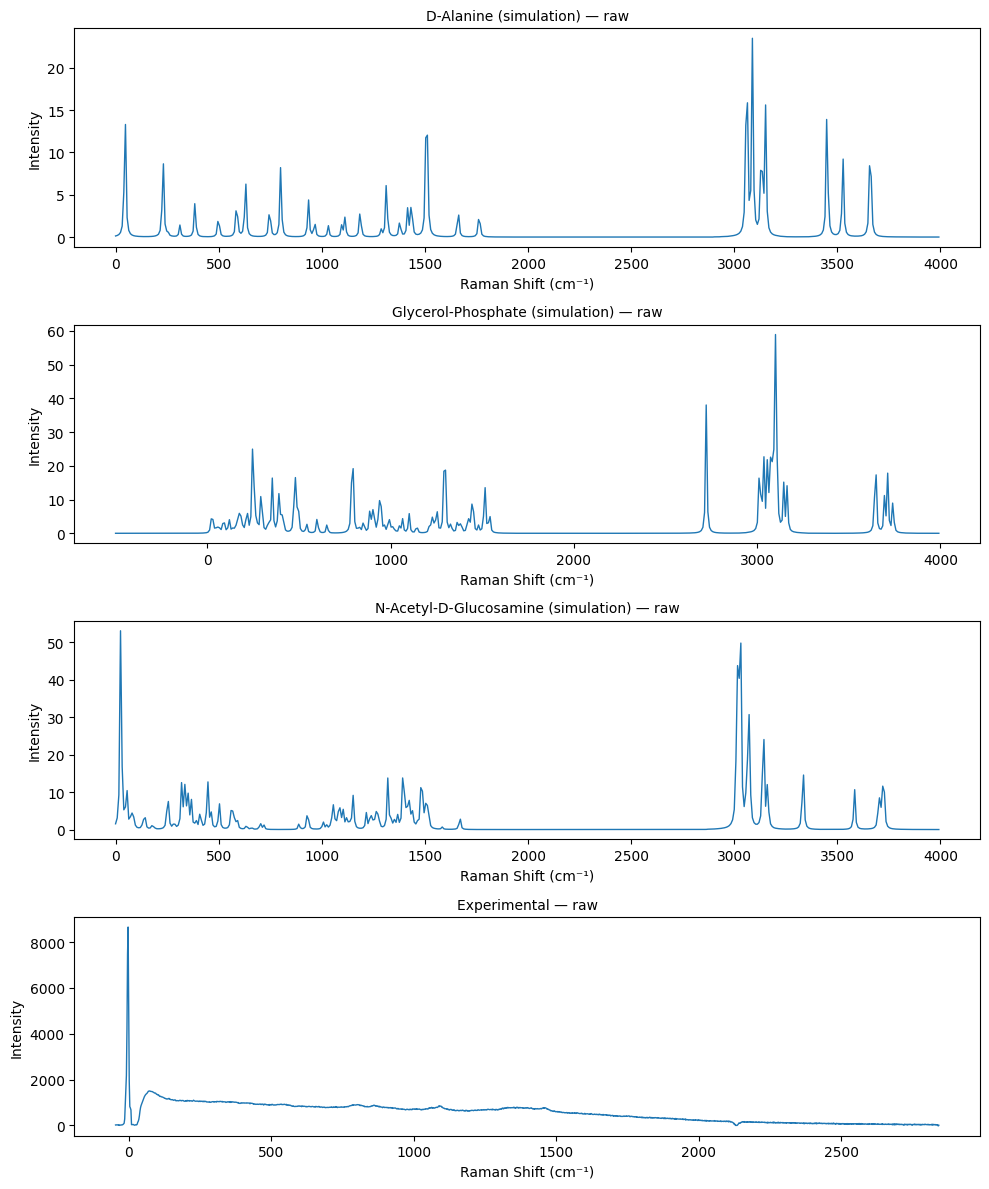

In [137]:
# CELL 6 — RAW PREVIEW PLOTS (no processing)

datasets = [
    (df_da_raw,  "D-Alanine (simulation) — raw"),
    (df_gp_raw,  "Glycerol-Phosphate (simulation) — raw"),
    (df_glc_raw, "N-Acetyl-D-Glucosamine (simulation) — raw"),
    (df_exp_raw, "Experimental — raw"),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=False)
for ax, (df, title) in zip(axes, datasets):
    ax.plot(df["RamanShift"], df["Intensity"], lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Raman Shift (cm⁻¹)")
    ax.set_ylabel("Intensity")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "00_raw_preview.png"), dpi=150)
plt.show()

In [138]:
# CELL 7 — HELPER FUNCTIONS

def restrict_range(df, xmin, xmax):
    """Keep only rows within [xmin, xmax]."""
    return df[(df['RamanShift'] >= xmin) & (df['RamanShift'] <= xmax)].copy().reset_index(drop=True)


def minmax_normalize(y):
    """Min-max normalize array to [0, 1]."""
    mn, mx = y.min(), y.max()
    return (y - mn) / (mx - mn) if mx > mn else np.zeros_like(y)


def als_baseline(y, lam=1e5, p=0.01, niter=10):
    """Asymmetric Least Squares baseline estimation (Eilers & Boelens 2005).
    lam  : smoothness penalty
    p    : asymmetry (fraction of points below baseline)
    """
    from scipy.sparse import diags, csc_matrix
    from scipy.sparse.linalg import spsolve
    L = len(y)
    D = diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
    H = lam * D.T @ D
    w = np.ones(L)
    for _ in range(niter):
        W = diags(w)
        Z = csc_matrix(W + H)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z


def smooth_signal(y, window=11, poly=3):
    """Savitzky-Golay smoothing (experimental data only)."""
    window = window if window % 2 == 1 else window + 1  # must be odd
    return savgol_filter(y, window_length=window, polyorder=poly)


def interpolate_safe(df, x_common):
    """Linearly interpolate df onto x_common; only within the data's own range.
    Points outside [df.RamanShift.min(), df.RamanShift.max()] are NaN (not extrapolated).
    """
    f = interp1d(df['RamanShift'], df['Intensity'], kind='linear',
                 bounds_error=False, fill_value=np.nan)
    return f(x_common)

In [139]:
# CELL 8 — PROCESS SIMULATION SPECTRA
# Steps: restrict → scale shift → re-sort → min-max normalise

def process_simulation(df_raw):
    df = restrict_range(df_raw, xmin, xmax).copy()
    if apply_scaling:
        df['RamanShift'] = df['RamanShift'] * scale_factor
    df.sort_values('RamanShift', inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['Intensity'] = minmax_normalize(df['Intensity'].values)
    return df


df_da  = process_simulation(df_da_raw)
df_gp  = process_simulation(df_gp_raw)
df_glc = process_simulation(df_glc_raw)

for name, df in [('D-Alanine', df_da), ('Glycerol-Phosphate', df_gp), ('N-Acetyl-D-Glucosamine', df_glc)]:
    print(f'{name}: {len(df)} points | shift {df.RamanShift.min():.1f}–{df.RamanShift.max():.1f} cm⁻¹ | intensity [{df.Intensity.min():.3f}, {df.Intensity.max():.3f}]')

D-Alanine: 226 points | shift 194.0–1940.0 cm⁻¹ | intensity [0.000, 1.000]
Glycerol-Phosphate: 200 points | shift 195.9–1933.2 cm⁻¹ | intensity [0.000, 1.000]
N-Acetyl-D-Glucosamine: 226 points | shift 194.0–1940.0 cm⁻¹ | intensity [0.000, 1.000]


In [140]:
# CELL 9 — PROCESS EXPERIMENTAL SPECTRUM
# Steps: restrict → ALS baseline → optional smoothing → min-max normalise

APPLY_SMOOTHING = False  # set True if spectrum appears noisy

df_exp = restrict_range(df_exp_raw, xmin, xmax).copy()

df_exp['Raw']       = df_exp['Intensity'].values
df_exp['Baseline']  = als_baseline(df_exp['Raw'].values, lam=1e5, p=0.01)
df_exp['Corrected'] = df_exp['Raw'] - df_exp['Baseline']
df_exp['Corrected'] = df_exp['Corrected'].clip(lower=0)  # no negative intensities

if APPLY_SMOOTHING:
    df_exp['Smoothed']  = smooth_signal(df_exp['Corrected'].values)
    working = df_exp['Smoothed'].values
else:
    working = df_exp['Corrected'].values

df_exp['Intensity_norm'] = minmax_normalize(working)
df_exp['Intensity']      = df_exp['Intensity_norm']  # unified column for downstream

print(f'Experimental: {len(df_exp)} points | shift {df_exp.RamanShift.min():.1f}–{df_exp.RamanShift.max():.1f} cm⁻¹')
print(f'Baseline range : {df_exp.Baseline.min():.4g} – {df_exp.Baseline.max():.4g}')
print(f'Corrected range: {df_exp.Corrected.min():.4g} – {df_exp.Corrected.max():.4g}')
print(f'Normalised range: {df_exp.Intensity_norm.min():.3f} – {df_exp.Intensity_norm.max():.3f}')
print(f'Smoothing applied: {APPLY_SMOOTHING}')

Experimental: 1155 points | shift 200.8–1999.0 cm⁻¹
Baseline range : 210.8 – 1064
Corrected range: 0 – 193.1
Normalised range: 0.000 – 1.000
Smoothing applied: False


In [141]:
# CELL 10 — DETECT SHARED VALID RANGE

all_dfs = {'D-Alanine': df_da, 'Glycerol-Phosphate': df_gp,
           'N-Acetyl-D-Glucosamine': df_glc, 'Experimental': df_exp}

shared_min = max(df['RamanShift'].min() for df in all_dfs.values())
shared_max = min(df['RamanShift'].max() for df in all_dfs.values())

assert shared_min < shared_max, 'No overlapping range found across spectra!'

for name, df in all_dfs.items():
    print(f'  {name}: {df.RamanShift.min():.1f} – {df.RamanShift.max():.1f} cm⁻¹')
print(f'\nShared valid range: {shared_min:.1f} – {shared_max:.1f} cm⁻¹')

  D-Alanine: 194.0 – 1940.0 cm⁻¹
  Glycerol-Phosphate: 195.9 – 1933.2 cm⁻¹
  N-Acetyl-D-Glucosamine: 194.0 – 1940.0 cm⁻¹
  Experimental: 200.8 – 1999.0 cm⁻¹

Shared valid range: 200.8 – 1933.2 cm⁻¹


In [142]:
# CELL 11 — BUILD COMMON GRID

x_common = np.arange(np.ceil(shared_min), np.floor(shared_max) + 1, 1.0)

y_da  = interpolate_safe(df_da,  x_common)
y_gp  = interpolate_safe(df_gp,  x_common)
y_glc = interpolate_safe(df_glc, x_common)
y_exp = interpolate_safe(df_exp[['RamanShift','Intensity']], x_common)

# Drop any grid points where any spectrum has NaN
valid = ~(np.isnan(y_da) | np.isnan(y_gp) | np.isnan(y_glc) | np.isnan(y_exp))
x_common, y_da, y_gp, y_glc, y_exp = (arr[valid] for arr in (x_common, y_da, y_gp, y_glc, y_exp))

print(f'Common grid: {len(x_common)} points | {x_common[0]:.1f} – {x_common[-1]:.1f} cm⁻¹')
print(f'All arrays same length: {len({len(a) for a in (x_common,y_da,y_gp,y_glc,y_exp)}) == 1}')

Common grid: 1733 points | 201.0 – 1933.0 cm⁻¹
All arrays same length: True


In [143]:
# CELL 12 — QUALITY CHECK

arrays = {'y_da': y_da, 'y_gp': y_gp, 'y_glc': y_glc, 'y_exp': y_exp}

print(f'Grid size    : {len(x_common)} points')
print(f'Shared range : {x_common[0]:.1f} – {x_common[-1]:.1f} cm⁻¹')
print()
for name, arr in arrays.items():
    nan_count = np.isnan(arr).sum()
    print(f'{name}: NaN={nan_count} | min={arr.min():.4f} | max={arr.max():.4f}')

Grid size    : 1733 points
Shared range : 201.0 – 1933.0 cm⁻¹

y_da: NaN=0 | min=0.0000 | max=0.9979
y_gp: NaN=0 | min=0.0000 | max=0.9791
y_glc: NaN=0 | min=0.0000 | max=0.9759
y_exp: NaN=0 | min=0.0000 | max=0.9910


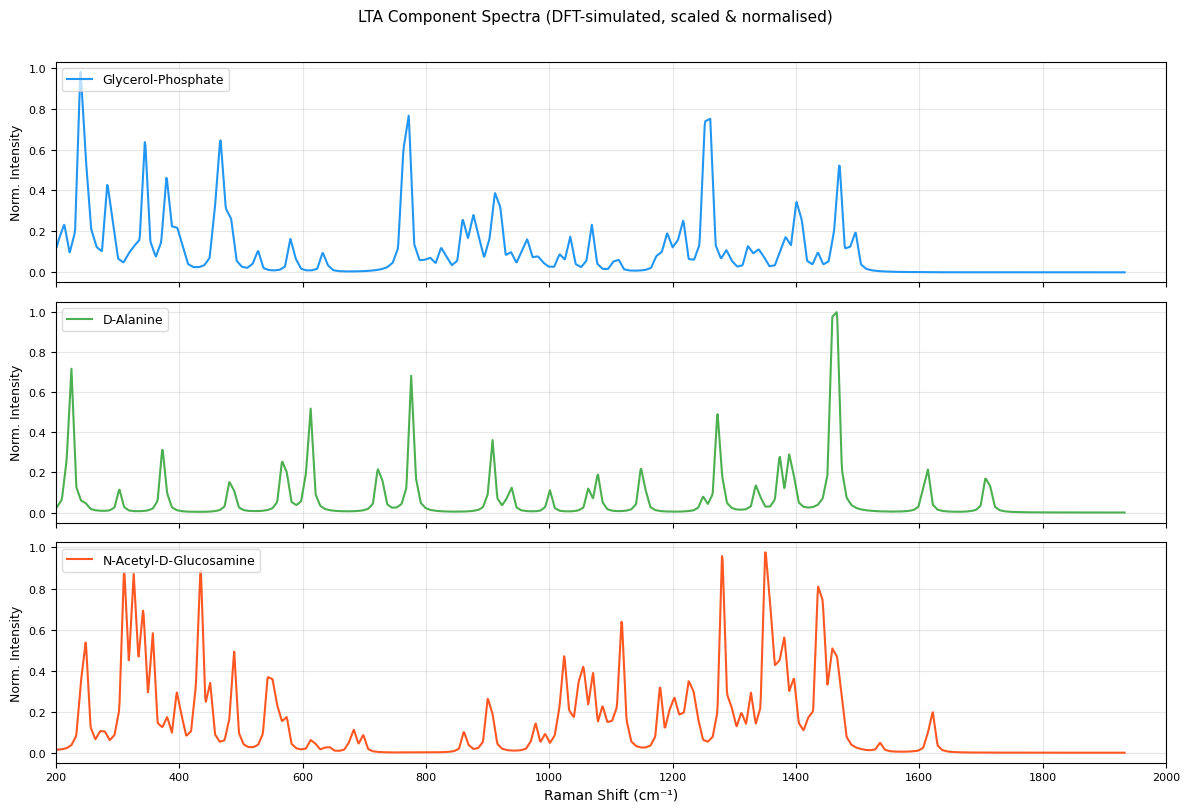

In [144]:
# CELL 13 — INDIVIDUAL COMPONENT SPECTRA

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

components = [
    (y_gp,  'Glycerol-Phosphate',      '#2196F3'),
    (y_da,  'D-Alanine',               '#4CAF50'),
    (y_glc, 'N-Acetyl-D-Glucosamine',  '#FF5722'),
]

for ax, (y, label, color) in zip(axes, components):
    ax.plot(x_common, y, lw=1.5, color=color, label=label)
    ax.set_xlim(200, 2000)
    ax.set_ylabel('Norm. Intensity', fontsize=9)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
fig.suptitle('LTA Component Spectra (DFT-simulated, scaled & normalised)', fontsize=11, y=1.01)
plt.tight_layout()

for ext in ('png', 'svg', 'pdf'):
    plt.savefig(os.path.join(output_dir, f'individual_components.{ext}'), dpi=150, bbox_inches='tight')
plt.show()

### DFT frequency scaling

DFT harmonic frequencies are systematically overestimated (~4–8%) due to neglect of anharmonicity and basis-set incompleteness. Multiplying all simulated Raman shifts by a scale factor (here **0.97**) brings the predicted band positions into alignment with experimental values. The correction is purely a rigid shift of the x-axis and does not alter relative intensities.

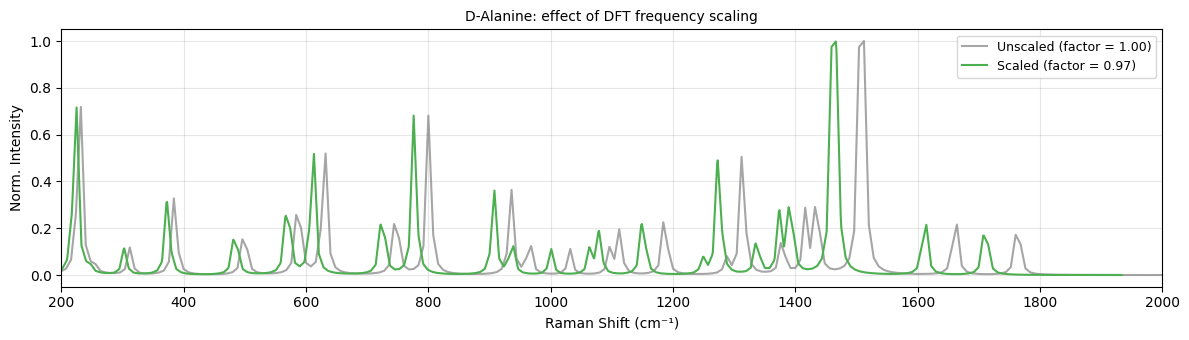

In [145]:
# CELL 14 — OPTIONAL SCALE FACTOR CHECK (D-Alanine example)

# Unscaled: restrict raw to shared range without applying scale_factor
df_da_unscaled = restrict_range(df_da_raw, xmin, xmax).copy()
df_da_unscaled['Intensity'] = minmax_normalize(df_da_unscaled['Intensity'].values)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df_da_unscaled['RamanShift'], df_da_unscaled['Intensity'],
        lw=1.5, color='gray', alpha=0.7, label=f'Unscaled (factor = 1.00)')
ax.plot(x_common, y_da, lw=1.5, color='#4CAF50', label=f'Scaled (factor = {scale_factor})')
ax.set_xlim(200, 2000)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
ax.set_ylabel('Norm. Intensity', fontsize=10)
ax.set_title('D-Alanine: effect of DFT frequency scaling', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scaling_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [146]:
# CELL 15 — COMPOSITE MODELS

# Equal-weight model
LTA_equal = minmax_normalize((y_gp + y_da + y_glc) / 3)

# Manual weighted model
w_gp, w_da, w_glc = 0.50, 0.20, 0.30
assert abs(w_gp + w_da + w_glc - 1.0) < 1e-9, 'Weights must sum to 1'
LTA_manual = minmax_normalize(w_gp * y_gp + w_da * y_da + w_glc * y_glc)

df_composite = pd.DataFrame({
    'RamanShift': x_common,
    'LTA_equal':  LTA_equal,
    'LTA_manual': LTA_manual,
})
save_dataframe(df_composite, 'composite_models.csv')
print(f'Weights — GP: {w_gp}, DA: {w_da}, GLC: {w_glc}')
print(f'LTA_equal  range: {LTA_equal.min():.3f} – {LTA_equal.max():.3f}')
print(f'LTA_manual range: {LTA_manual.min():.3f} – {LTA_manual.max():.3f}')

Saved → C:\Users\sukes\Downloads\lta\results\composite_models.csv
Weights — GP: 0.5, DA: 0.2, GLC: 0.3
LTA_equal  range: 0.000 – 1.000
LTA_manual range: 0.000 – 1.000


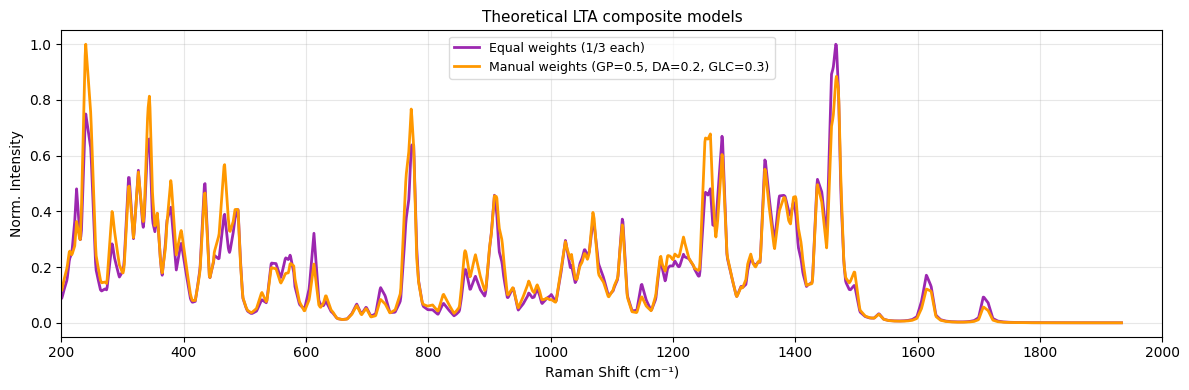

In [147]:
# CELL 16 — PLOT COMPOSITE MODELS

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_common, LTA_equal,  lw=2, color='#9C27B0', label='Equal weights (1/3 each)')
ax.plot(x_common, LTA_manual, lw=2, color='#FF9800',
        label=f'Manual weights (GP={w_gp}, DA={w_da}, GLC={w_glc})')
ax.set_xlim(200, 2000)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
ax.set_ylabel('Norm. Intensity', fontsize=10)
ax.set_title('Theoretical LTA composite models', fontsize=11)
ax.legend(fontsize=9, framealpha=0.7)
ax.grid(alpha=0.3)
plt.tight_layout()

for ext in ('png', 'svg', 'pdf'):
    plt.savefig(os.path.join(output_dir, f'composite_models.{ext}'), dpi=150, bbox_inches='tight')
plt.show()

In [148]:
# CELL 17 — ROBUST PEAK DETECTION FUNCTION

def detect_peaks(x, y, top_n=20):
    """Detect peaks in spectrum (x, y) and return top_n ranked by intensity.
    
    Prominence threshold is adaptive: 5% of the signal's intensity range.
    Distance threshold: 10 data points (avoids splitting one broad peak).
    """
    intensity_range = y.max() - y.min()
    prominence = PEAK_PROMINENCE * intensity_range
    
    indices, props = find_peaks(
        y,
        prominence=prominence,
        distance=PEAK_DISTANCE,
        height=PEAK_HEIGHT,
    )
    
    if len(indices) == 0:
        return pd.DataFrame(columns=['Rank', 'RamanShift', 'Intensity'])
    
    df_peaks = pd.DataFrame({
        'RamanShift': x[indices],
        'Intensity':  y[indices],
    })
    df_peaks = (df_peaks
                .sort_values('Intensity', ascending=False)
                .head(top_n)
                .reset_index(drop=True))
    df_peaks.index += 1
    df_peaks.index.name = 'Rank'
    return df_peaks.reset_index()

In [149]:
# CELL 18 — EXTRACT PEAKS

peak_targets = [
    (y_gp,       'Glycerol-Phosphate',     'peaks_gp.csv'),
    (y_da,       'D-Alanine',              'peaks_da.csv'),
    (y_glc,      'N-Acetyl-D-Glucosamine', 'peaks_glc.csv'),
    (LTA_manual, 'LTA Manual',             'peaks_lta_manual.csv'),
]

for y, name, fname in peak_targets:
    df_pk = detect_peaks(x_common, y, top_n=20)
    save_dataframe(df_pk, fname)
    print(f'\n{name} — top 5 peaks:')
    print(df_pk.head(5).to_string(index=False))

Saved → C:\Users\sukes\Downloads\lta\results\peaks_gp.csv

Glycerol-Phosphate — top 5 peaks:
 Rank  RamanShift  Intensity
    1       240.0   0.979102
    2       772.0   0.765745
    3      1261.0   0.750418
    4       467.0   0.644748
    5       344.0   0.636264
Saved → C:\Users\sukes\Downloads\lta\results\peaks_da.csv

D-Alanine — top 5 peaks:
 Rank  RamanShift  Intensity
    1      1466.0   0.997909
    2       225.0   0.716125
    3       776.0   0.681369
    4       613.0   0.517783
    5      1273.0   0.489919
Saved → C:\Users\sukes\Downloads\lta\results\peaks_glc.csv

N-Acetyl-D-Glucosamine — top 5 peaks:
 Rank  RamanShift  Intensity
    1      1350.0   0.975897
    2      1280.0   0.957933
    3       435.0   0.884730
    4       310.0   0.873963
    5       326.0   0.871718
Saved → C:\Users\sukes\Downloads\lta\results\peaks_lta_manual.csv

LTA Manual — top 5 peaks:
 Rank  RamanShift  Intensity
    1       240.0   1.000000
    2      1467.0   0.884799
    3       344.0   0.8

In [150]:
# CELL 19 — PREPARE FITTING MATRIX
# A · w = y_exp  (all arrays on x_common grid, same as plotting)

from scipy.optimize import nnls

A = np.column_stack([y_gp, y_da, y_glc])   # shape (N, 3)
b = y_exp                                   # shape (N,)

print(f'Fitting matrix A : {A.shape}')
print(f'Target vector b  : {b.shape}')
print(f'Any NaN in A     : {np.isnan(A).any()}')
print(f'Any NaN in b     : {np.isnan(b).any()}')

Fitting matrix A : (1733, 3)
Target vector b  : (1733,)
Any NaN in A     : False
Any NaN in b     : False


In [151]:
# CELL 20 — NNLS FIT

w_raw, residual_norm = nnls(A, b)

# Normalise so weights sum to 1
w_sum = w_raw.sum()
w_norm = w_raw / w_sum if w_sum > 0 else w_raw

w_gp_fit, w_da_fit, w_glc_fit = w_norm

print('NNLS fitted weights (normalised):')
print(f'  Glycerol-Phosphate     : {w_gp_fit:.4f}  ({w_gp_fit*100:.1f}%)')
print(f'  D-Alanine              : {w_da_fit:.4f}  ({w_da_fit*100:.1f}%)')
print(f'  N-Acetyl-D-Glucosamine : {w_glc_fit:.4f}  ({w_glc_fit*100:.1f}%)')
print(f'  Sum                    : {w_norm.sum():.6f}')

NNLS fitted weights (normalised):
  Glycerol-Phosphate     : 0.2011  (20.1%)
  D-Alanine              : 0.3953  (39.5%)
  N-Acetyl-D-Glucosamine : 0.4035  (40.4%)
  Sum                    : 1.000000


In [152]:
# CELL 21 — BUILD OPTIMIZED MODEL

LTA_fit = w_gp_fit * y_gp + w_da_fit * y_da + w_glc_fit * y_glc

# Normalise to [0,1] for fair comparison with y_exp (already normalised)
LTA_fit = minmax_normalize(LTA_fit)

print(f'LTA_fit range: {LTA_fit.min():.4f} — {LTA_fit.max():.4f}')
print(f'y_exp   range: {y_exp.min():.4f} — {y_exp.max():.4f}')

LTA_fit range: 0.0000 — 1.0000
y_exp   range: 0.0000 — 0.9910


In [153]:
# CELL 22 — METRICS

from sklearn.metrics import r2_score

rmse    = np.sqrt(np.mean((y_exp - LTA_fit) ** 2))
mae     = np.mean(np.abs(y_exp - LTA_fit))
r2      = r2_score(y_exp, LTA_fit)
pearson = np.corrcoef(y_exp, LTA_fit)[0, 1]

metrics = {
    'RMSE':    rmse,
    'MAE':     mae,
    'R²':      r2,
    'Pearson': pearson,
}

print('\n── Fit Quality Metrics ────────────────')
for k, v in metrics.items():
    print(f'  {k:<10}: {v:.6f}')
print('──────────────────────────────────────')


── Fit Quality Metrics ────────────────
  RMSE      : 0.192762
  MAE       : 0.136253
  R²        : -0.294273
  Pearson   : 0.344771
──────────────────────────────────────


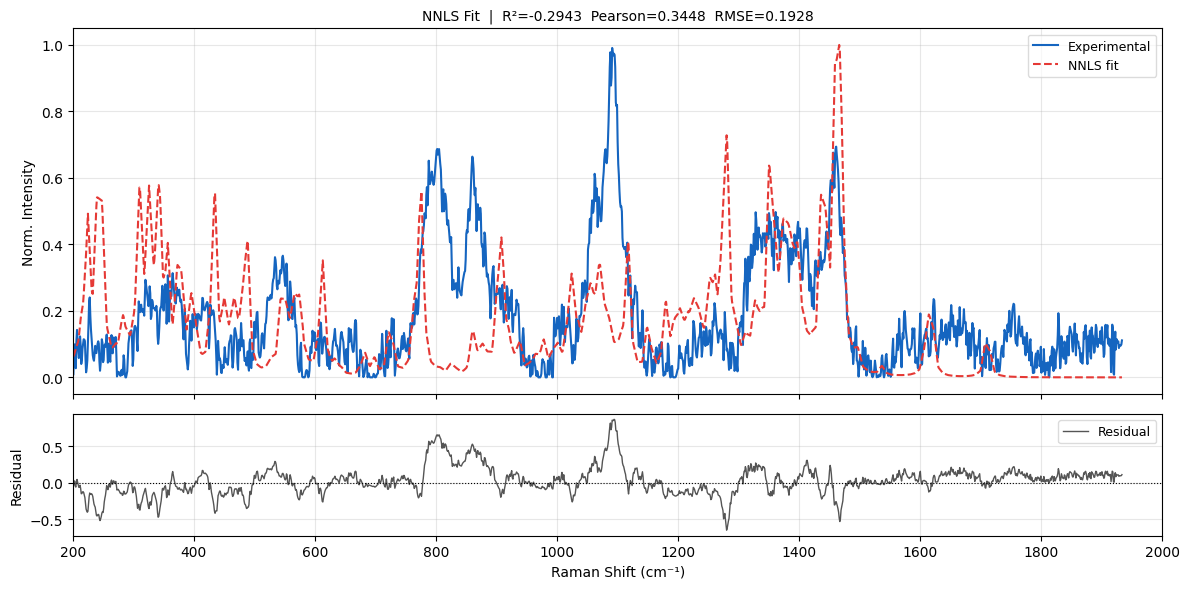

In [154]:
# CELL 23 — RESIDUAL ANALYSIS

residual = y_exp - LTA_fit

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Top panel
ax1.plot(x_common, y_exp,   lw=1.5, color='#1565C0', label='Experimental')
ax1.plot(x_common, LTA_fit, lw=1.5, color='#E53935', linestyle='--', label='NNLS fit')
ax1.set_ylabel('Norm. Intensity', fontsize=10)
ax1.set_title(f'NNLS Fit  |  R²={r2:.4f}  Pearson={pearson:.4f}  RMSE={rmse:.4f}', fontsize=10)
ax1.legend(fontsize=9, framealpha=0.7)
ax1.grid(alpha=0.3)

# Bottom panel
ax2.plot(x_common, residual, lw=1, color='#555555', label='Residual')
ax2.axhline(0, color='black', lw=0.8, linestyle=':')
ax2.set_ylabel('Residual', fontsize=10)
ax2.set_xlabel('Raman Shift (cm⁻¹)', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.7)
ax2.grid(alpha=0.3)

ax1.set_xlim(200, 2000)
plt.tight_layout()

for ext in ('png', 'svg', 'pdf'):
    plt.savefig(os.path.join(output_dir, f'fit_and_residual.{ext}'), dpi=150, bbox_inches='tight')
plt.show()

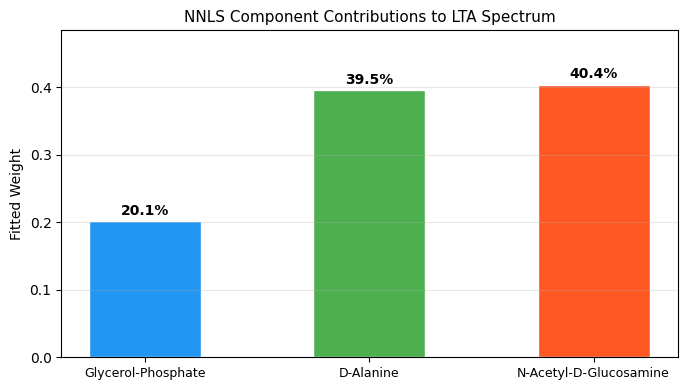

In [155]:
# CELL 24 — FITTED WEIGHTS BAR CHART

labels  = ['Glycerol-Phosphate', 'D-Alanine', 'N-Acetyl-D-Glucosamine']
weights = [w_gp_fit, w_da_fit, w_glc_fit]
colors  = ['#2196F3', '#4CAF50', '#FF5722']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, weights, color=colors, edgecolor='white', width=0.5)

for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{w*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, max(weights) * 1.2)
ax.set_ylabel('Fitted Weight', fontsize=10)
ax.set_title('NNLS Component Contributions to LTA Spectrum', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fitted_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

In [156]:
# CELL 25 — SAVE NUMERICAL RESULTS

# 1. Optimised fit spectrum
save_dataframe(
    pd.DataFrame({'RamanShift': x_common, 'y_exp': y_exp, 'LTA_fit': LTA_fit}),
    'optimized_fit_spectrum.csv'
)

# 2. Fit metrics
save_dataframe(
    pd.DataFrame([metrics]),
    'fit_metrics.csv'
)

# 3. Fitted weights
save_dataframe(
    pd.DataFrame({
        'Component': labels,
        'Weight':    weights,
        'Percent':   [w * 100 for w in weights],
    }),
    'fitted_weights.csv'
)

# 4. Residual
save_dataframe(
    pd.DataFrame({'RamanShift': x_common, 'Residual': residual}),
    'residual.csv'
)

Saved → C:\Users\sukes\Downloads\lta\results\optimized_fit_spectrum.csv
Saved → C:\Users\sukes\Downloads\lta\results\fit_metrics.csv
Saved → C:\Users\sukes\Downloads\lta\results\fitted_weights.csv
Saved → C:\Users\sukes\Downloads\lta\results\residual.csv


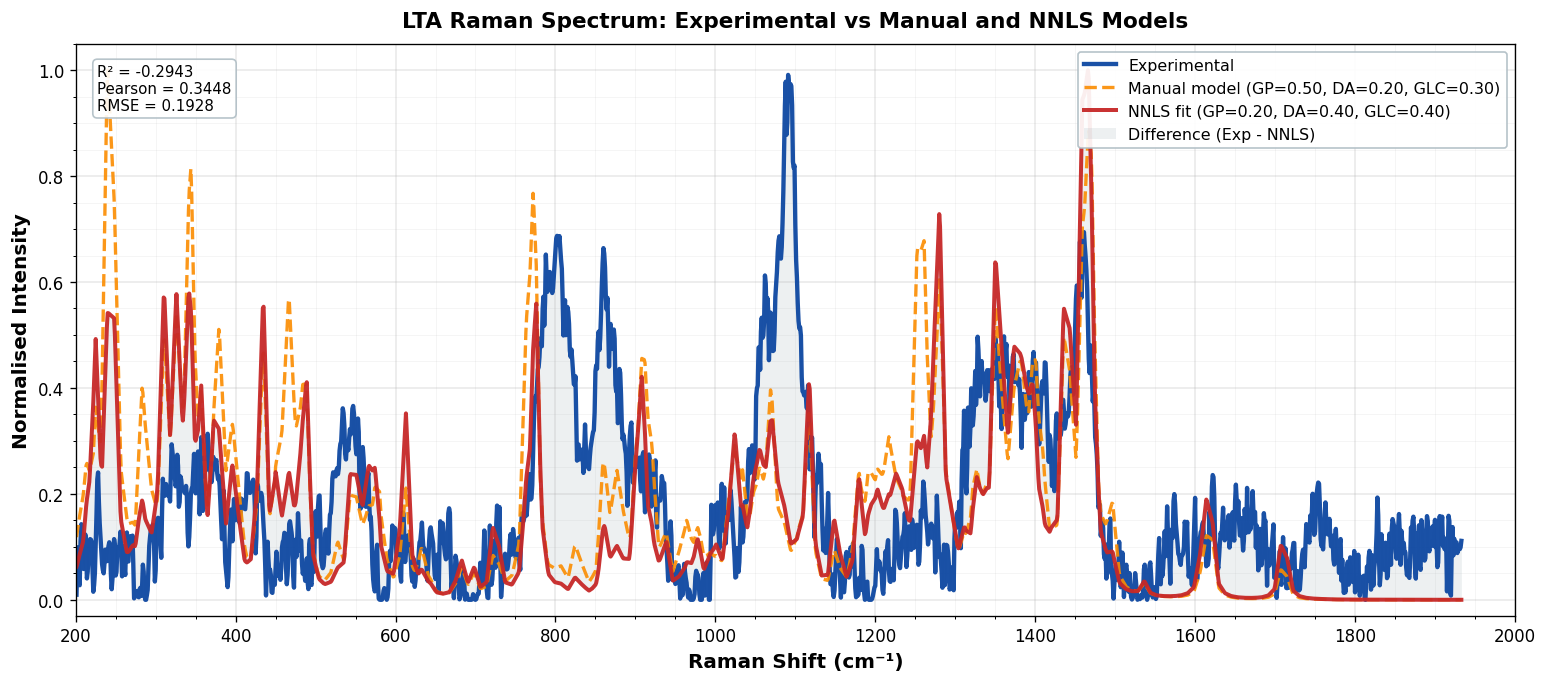

In [157]:
# CELL 26 — FINAL OVERLAY FIGURE (IMPROVED)

fig, ax = plt.subplots(figsize=(13, 5.8), dpi=120)

# Main curves
ax.plot(x_common, y_exp, lw=2.6, color='#0D47A1', alpha=0.95, label='Experimental')
ax.plot(
    x_common,
    LTA_manual,
    lw=2.0,
    color='#FB8C00',
    linestyle='--',
    alpha=0.9,
    label=f'Manual model (GP={w_gp:.2f}, DA={w_da:.2f}, GLC={w_glc:.2f})',
)
ax.plot(
    x_common,
    LTA_fit,
    lw=2.4,
    color='#C62828',
    linestyle='-',
    alpha=0.95,
    label=f'NNLS fit (GP={w_gp_fit:.2f}, DA={w_da_fit:.2f}, GLC={w_glc_fit:.2f})',
)

# Residual shading helps visually identify mismatch zones.
ax.fill_between(
    x_common,
    y_exp,
    LTA_fit,
    color='#90A4AE',
    alpha=0.16,
    linewidth=0,
    label='Difference (Exp - NNLS)',
)

ax.set_xlim(200, 2000)
ax.set_ylim(bottom=min(y_exp.min(), LTA_manual.min(), LTA_fit.min()) - 0.03)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalised Intensity', fontsize=12, fontweight='bold')
ax.set_title('LTA Raman Spectrum: Experimental vs Manual and NNLS Models', fontsize=13, fontweight='bold', pad=10)

# Improve readability with major and minor grids.
ax.minorticks_on()
ax.grid(which='major', alpha=0.30, linewidth=0.9)
ax.grid(which='minor', alpha=0.14, linewidth=0.5)
ax.tick_params(axis='both', labelsize=10)

legend = ax.legend(loc='upper right', fontsize=9.5, framealpha=0.92, ncol=1)
legend.get_frame().set_edgecolor('#B0BEC5')

# Small text box with fit quality in the same plot.
metrics_text = f'R² = {r2:.4f}\nPearson = {pearson:.4f}\nRMSE = {rmse:.4f}'
ax.text(
    0.015,
    0.965,
    metrics_text,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#B0BEC5', alpha=0.9),
)

plt.tight_layout()
for ext in ('png', 'svg', 'pdf'):
    plt.savefig(os.path.join(output_dir, f'final_overlay.{ext}'), dpi=300, bbox_inches='tight')
plt.show()

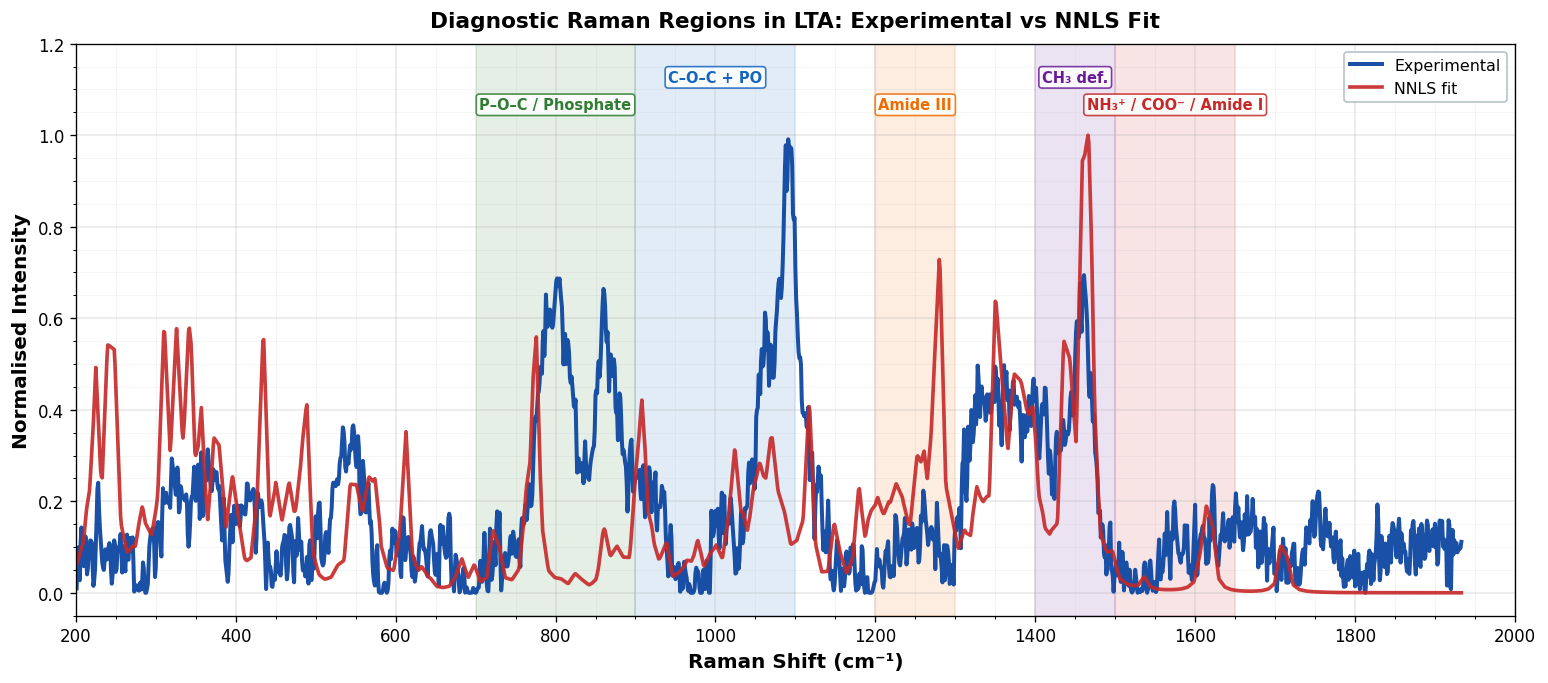

In [158]:
# CELL 27 — REGION ANNOTATION FIGURE (IMPROVED)

regions = [
    (700, 900, '#2E7D32', 'P–O–C / Phosphate'),
    (900, 1100, '#1565C0', 'C–O–C + PO'),
    (1200, 1300, '#EF6C00', 'Amide III'),
    (1400, 1500, '#6A1B9A', 'CH₃ def.'),
    (1500, 1650, '#C62828', 'NH₃⁺ / COO⁻ / Amide I'),
]

fig, ax = plt.subplots(figsize=(13, 5.8), dpi=120)
ax.plot(x_common, y_exp, lw=2.4, color='#0D47A1', alpha=0.95, label='Experimental')
ax.plot(x_common, LTA_fit, lw=2.2, color='#C62828', linestyle='-', alpha=0.9, label='NNLS fit')

x_min, x_max = 200, 2000
ymax = float(max(y_exp.max(), LTA_fit.max()))

for idx, (xlo, xhi, color, label) in enumerate(regions):
    # Shade only if the region overlaps the visible x-range.
    if xhi < x_min or xlo > x_max:
        continue

    left = max(xlo, x_min)
    right = min(xhi, x_max)
    ax.axvspan(left, right, alpha=0.12, color=color, zorder=0)

    y_text = ymax * (1.05 if idx % 2 == 0 else 1.11)
    ax.text(
        (left + right) / 2,
        y_text,
        label,
        ha='center',
        va='bottom',
        fontsize=8.8,
        color=color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor=color, alpha=0.85),
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(top=ymax * 1.2)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalised Intensity', fontsize=12, fontweight='bold')
ax.set_title('Diagnostic Raman Regions in LTA: Experimental vs NNLS Fit', fontsize=13, fontweight='bold', pad=10)

ax.minorticks_on()
ax.grid(which='major', alpha=0.30, linewidth=0.9)
ax.grid(which='minor', alpha=0.14, linewidth=0.5)
ax.tick_params(axis='both', labelsize=10)

legend = ax.legend(loc='upper right', fontsize=9.5, framealpha=0.92)
legend.get_frame().set_edgecolor('#B0BEC5')

plt.tight_layout()
for ext in ('png', 'svg', 'pdf'):
    plt.savefig(os.path.join(output_dir, f'annotated_regions.{ext}'), dpi=300, bbox_inches='tight')
plt.show()

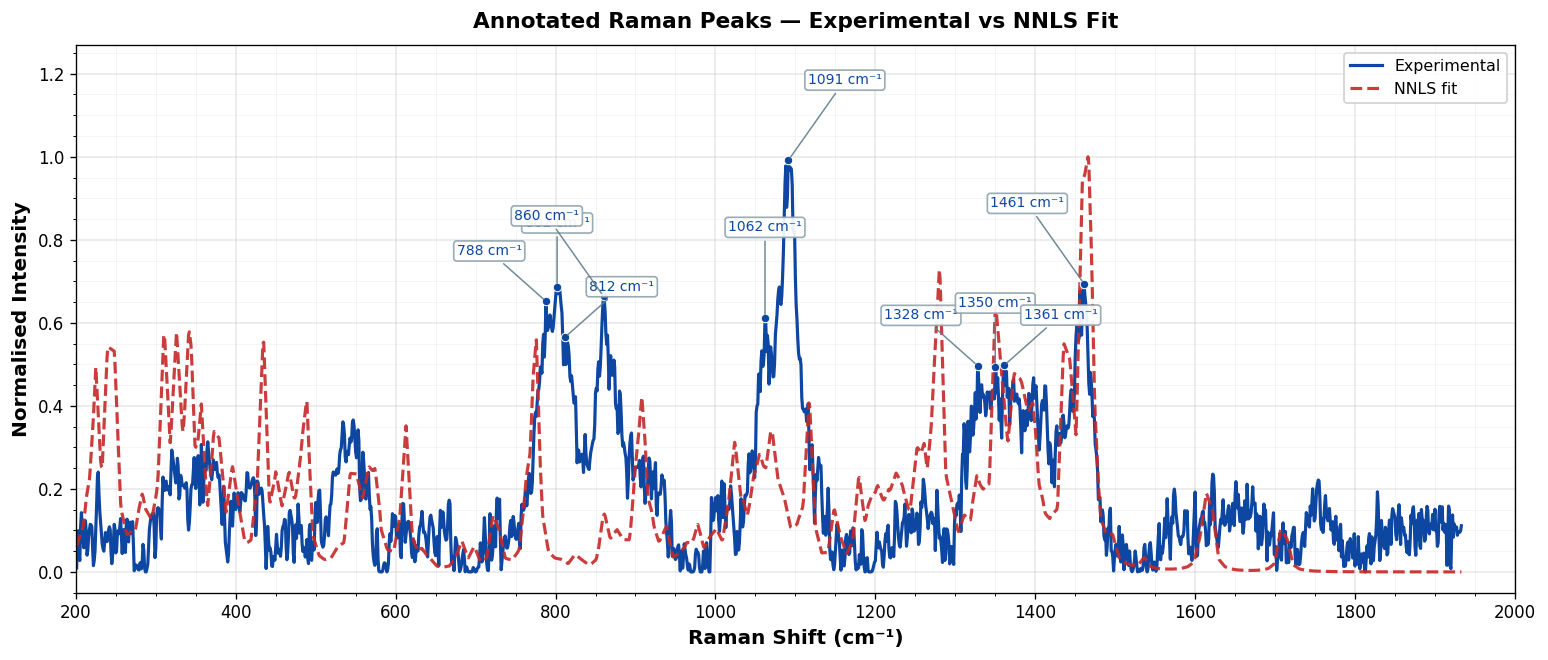

In [159]:
# CELL 28 — SELECTIVE PEAK LABELING
# Annotate top peaks of experimental spectrum with clearer, non-overlapping labels.

df_exp_peaks = detect_peaks(x_common, y_exp, top_n=12)
df_exp_peaks = df_exp_peaks.head(10).sort_values('RamanShift').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.6), dpi=120)
ax.plot(x_common, y_exp, lw=1.9, color='#0D47A1', label='Experimental', zorder=2)
ax.plot(x_common, LTA_fit, lw=1.9, color='#C62828', linestyle='--', alpha=0.9, label='NNLS fit', zorder=2)

# Peak markers make it easier to visually bind each text label to a local maximum.
ax.scatter(
    df_exp_peaks['RamanShift'],
    df_exp_peaks['Intensity'],
    s=26,
    color='#0D47A1',
    edgecolor='white',
    linewidth=0.6,
    zorder=4,
)

# Use alternating offset templates to reduce label collisions in dense regions.
offset_templates = [
    (-34, 26),
    (0, 34),
    (34, 26),
    (-34, 44),
    (0, 50),
    (34, 44),
]

for i, row in df_exp_peaks.iterrows():
    dx, dy = offset_templates[i % len(offset_templates)]
    ax.annotate(
        f"{int(row['RamanShift'])} cm⁻¹",
        xy=(row['RamanShift'], row['Intensity']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8.3,
        ha='center',
        va='bottom',
        color='#0D47A1',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#90A4AE', alpha=0.92),
        arrowprops=dict(arrowstyle='-', color='#607D8B', lw=0.9, alpha=0.9, shrinkA=2, shrinkB=2),
        zorder=5,
    )

ax.set_xlim(200, 2000)
ax.set_ylim(top=max(y_exp.max(), LTA_fit.max()) * 1.27)
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalised Intensity', fontsize=12, fontweight='bold')
ax.set_title('Annotated Raman Peaks — Experimental vs NNLS Fit', fontsize=13, fontweight='bold', pad=10)

ax.minorticks_on()
ax.grid(which='major', alpha=0.30, linewidth=0.9)
ax.grid(which='minor', alpha=0.14, linewidth=0.5)
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=9.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'annotated_peaks_final.png'), dpi=300, bbox_inches='tight')
plt.show()

## CELL 29 — Analysis Summary

> *This cell is auto-populated by the notebook variables after all cells have run.*

| Parameter | Value |
|-----------|-------|
| Simulation files | D-Alanine, Glycerol-Phosphate, N-Acetyl-D-Glucosamine |
| Experimental file | sec-10_power-70_i-10.xlsx |
| Shared Raman range | determined automatically from data overlap |
| DFT scaling factor | 0.97 (applied to simulated spectra only) |
| Baseline correction | ALS (lam=1e5, p=0.01) applied to experimental only |
| NNLS weights | see Cell 20 output |
| R² / RMSE / Pearson | see Cell 22 output |
| Matched regions | Phosphate (~800 cm⁻¹), C-O-C+PO (~1000 cm⁻¹), Amide III (~1250 cm⁻¹), CH₃ (~1450 cm⁻¹), Amide I (~1550–1650 cm⁻¹) |

> **Important**: The composite model is a **fragment-based linear approximation** built from three isolated molecular components (D-Alanine, Glycerol-Phosphate, GlcNAc). It is **not** a full quantum-chemical simulation of intact LTA. Intermolecular interactions, conformational averaging, and environmental effects are not captured. Fit quality reflects spectral overlap, not chemical identification.

In [2]:
# CELL 30 — TEXT REPORT EXPORT

import os
import numpy as np

# Make this cell resilient when run independently (without running all previous cells).
output_dir = globals().get('output_dir', 'results')
os.makedirs(output_dir, exist_ok=True)

x_vals = globals().get('x_common')
if x_vals is None:
    x_vals = globals().get('x_grid')
if x_vals is None and 'df_exp' in globals() and 'RamanShift' in df_exp.columns:
    x_vals = np.asarray(df_exp['RamanShift'].to_numpy(), dtype=float)

if x_vals is not None and len(x_vals) > 0:
    spectral_range_text = f"{float(np.nanmin(x_vals)):.0f} – {float(np.nanmax(x_vals)):.0f} cm⁻¹"
    grid_points_text = str(len(x_vals))
else:
    spectral_range_text = 'N/A (run preprocessing cells first)'
    grid_points_text = 'N/A'

scale_factor_val = globals().get('scale_factor', 'N/A')
apply_smoothing_val = globals().get('APPLY_SMOOTHING', 'N/A')
w_gp_fit_val = float(globals().get('w_gp_fit', np.nan))
w_da_fit_val = float(globals().get('w_da_fit', np.nan))
w_glc_fit_val = float(globals().get('w_glc_fit', np.nan))
rmse_val = float(globals().get('rmse', np.nan))
mae_val = float(globals().get('mae', np.nan))
r2_val = float(globals().get('r2', np.nan))
pearson_val = float(globals().get('pearson', np.nan))

report_lines = [
    '=' * 60,
    'LTA RAMAN SPECTROSCOPY ANALYSIS — SUMMARY REPORT',
    '=' * 60,
    '',
    '1. WORKFLOW',
    '   Load raw spectra → restrict range → scale (sim) / ALS (exp)',
    '   → normalise → common grid → NNLS fit → metrics → export',
    '',
    '2. PREPROCESSING',
    f'   Spectral range  : {spectral_range_text}',
    f'   DFT scale factor: {scale_factor_val} (simulation only)',
    '   Baseline        : ALS (lam=1e5, p=0.01) — experimental only',
    f'   Smoothing       : {apply_smoothing_val}',
    f'   Grid spacing    : 1 cm⁻¹ | {grid_points_text} points',
    '',
    '3. NNLS FITTED WEIGHTS',
    f'   Glycerol-Phosphate     : {w_gp_fit_val:.4f}  ({w_gp_fit_val*100:.1f}%)',
    f'   D-Alanine              : {w_da_fit_val:.4f}  ({w_da_fit_val*100:.1f}%)',
    f'   N-Acetyl-D-Glucosamine : {w_glc_fit_val:.4f}  ({w_glc_fit_val*100:.1f}%)',
    '',
    '4. FIT QUALITY METRICS',
    f'   RMSE    : {rmse_val:.6f}',
    f'   MAE     : {mae_val:.6f}',
    f'   R²      : {r2_val:.6f}',
    f'   Pearson : {pearson_val:.6f}',
    '',
    '5. INTERPRETATION',
    '   Glycerol-Phosphate contributes the phosphate backbone signal.',
    '   D-Alanine contributes amide/CH bands.',
    '   GlcNAc contributes glycan ring and amide I/III signals.',
    '   This is a fragment-based linear approximation, not a full',
    '   quantum simulation of intact LTA.',
    '',
    '6. OUTPUT FOLDER',
    f'   {output_dir}',
    '=' * 60,
]

report_path = os.path.join(output_dir, 'final_summary_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))
print(f'Report saved → {report_path}')

Report saved → results\final_summary_report.txt


In [4]:
# CELL 31 — MASTER EXCEL EXPORT

import os
import pandas as pd

output_dir = globals().get('output_dir', 'results')
os.makedirs(output_dir, exist_ok=True)
xlsx_path = os.path.join(output_dir, 'LTA_complete_results.xlsx')

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    # Peaks combined sheet (prefer in-memory data; fallback to previously exported peak CSVs)
    df_peaks_all = None
    if all(name in globals() for name in ('detect_peaks', 'x_common', 'y_gp', 'y_da', 'y_glc', 'LTA_fit')):
        df_peaks_all = pd.concat([
            detect_peaks(x_common, y_gp, top_n=20).assign(Component='Glycerol-Phosphate'),
            detect_peaks(x_common, y_da, top_n=20).assign(Component='D-Alanine'),
            detect_peaks(x_common, y_glc, top_n=20).assign(Component='N-Acetyl-D-Glucosamine'),
            detect_peaks(x_common, LTA_fit, top_n=20).assign(Component='LTA_fit'),
        ], ignore_index=True)
    else:
        peaks_sources = [
            ('peaks_gp.csv', 'Glycerol-Phosphate'),
            ('peaks_da.csv', 'D-Alanine'),
            ('peaks_glc.csv', 'N-Acetyl-D-Glucosamine'),
            ('peaks_lta_manual.csv', 'LTA_fit'),
        ]
        collected = []
        for filename, component in peaks_sources:
            path = os.path.join(output_dir, filename)
            if os.path.exists(path):
                df_tmp = pd.read_csv(path)
                if 'Component' not in df_tmp.columns:
                    df_tmp['Component'] = component
                collected.append(df_tmp)
        if collected:
            df_peaks_all = pd.concat(collected, ignore_index=True)

    if df_peaks_all is None:
        df_peaks_all = pd.DataFrame(columns=['RamanShift', 'Intensity', 'Component'])

    # Processed spectra sheets
    if 'df_gp' in globals() and {'RamanShift', 'Intensity'}.issubset(df_gp.columns):
        df_gp[['RamanShift', 'Intensity']].to_excel(writer, sheet_name='Processed_GP', index=False)
    if 'df_da' in globals() and {'RamanShift', 'Intensity'}.issubset(df_da.columns):
        df_da[['RamanShift', 'Intensity']].to_excel(writer, sheet_name='Processed_DA', index=False)
    if 'df_glc' in globals() and {'RamanShift', 'Intensity'}.issubset(df_glc.columns):
        df_glc[['RamanShift', 'Intensity']].to_excel(writer, sheet_name='Processed_GlcNAc', index=False)
    if 'df_exp' in globals() and {'RamanShift', 'Intensity'}.issubset(df_exp.columns):
        df_exp[['RamanShift', 'Intensity']].to_excel(writer, sheet_name='Processed_Experimental', index=False)

    # Composite sheets
    if all(name in globals() for name in ('x_common', 'LTA_manual')):
        pd.DataFrame({'RamanShift': x_common, 'Intensity': LTA_manual}).to_excel(
            writer, sheet_name='Composite_Manual', index=False
        )

    optimized_path = os.path.join(output_dir, 'optimized_fit_spectrum.csv')
    if all(name in globals() for name in ('x_common', 'y_exp', 'LTA_fit')):
        pd.DataFrame({'RamanShift': x_common, 'y_exp': y_exp, 'LTA_fit': LTA_fit}).to_excel(
            writer, sheet_name='Composite_Optimized', index=False
        )
    elif os.path.exists(optimized_path):
        pd.read_csv(optimized_path).to_excel(writer, sheet_name='Composite_Optimized', index=False)

    df_peaks_all.to_excel(writer, sheet_name='Peaks', index=False)

    # Metrics sheet
    if 'metrics' in globals() and isinstance(metrics, dict):
        pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    else:
        fit_metrics_path = os.path.join(output_dir, 'fit_metrics.csv')
        if os.path.exists(fit_metrics_path):
            pd.read_csv(fit_metrics_path).to_excel(writer, sheet_name='Metrics', index=False)

    # Weights sheet
    if all(name in globals() for name in ('labels', 'weights')):
        pd.DataFrame({'Component': labels, 'Weight': weights, 'Percent': [w * 100 for w in weights]}).to_excel(
            writer, sheet_name='Weights', index=False
        )
    else:
        fitted_weights_path = os.path.join(output_dir, 'fitted_weights.csv')
        if os.path.exists(fitted_weights_path):
            pd.read_csv(fitted_weights_path).to_excel(writer, sheet_name='Weights', index=False)

print(f'Excel workbook saved → {xlsx_path}')

Excel workbook saved → results\LTA_complete_results.xlsx


  Analysis completed successfully.
  Outputs saved to: results

  ✓  00_raw_preview.png
  ✓  individual_components.png/svg/pdf
  ✓  scaling_comparison.png
  ✓  composite_models.csv
  ✓  composite_models.png/svg/pdf
  ✓  peaks_gp.csv
  ✓  peaks_da.csv
  ✓  peaks_glc.csv
  ✓  peaks_lta_manual.csv
  ✓  optimized_fit_spectrum.csv
  ✓  fit_metrics.csv
  ✓  fitted_weights.csv
  ✓  residual.csv
  ✓  fit_and_residual.png/svg/pdf
  ✓  fitted_weights.png
  ✓  final_overlay.png/svg/pdf
  ✓  annotated_regions.png/svg/pdf
  ✓  annotated_peaks_final.png
  ✓  final_summary_report.txt
  ✓  LTA_complete_results.xlsx

  Preview Images

00_raw_preview.png


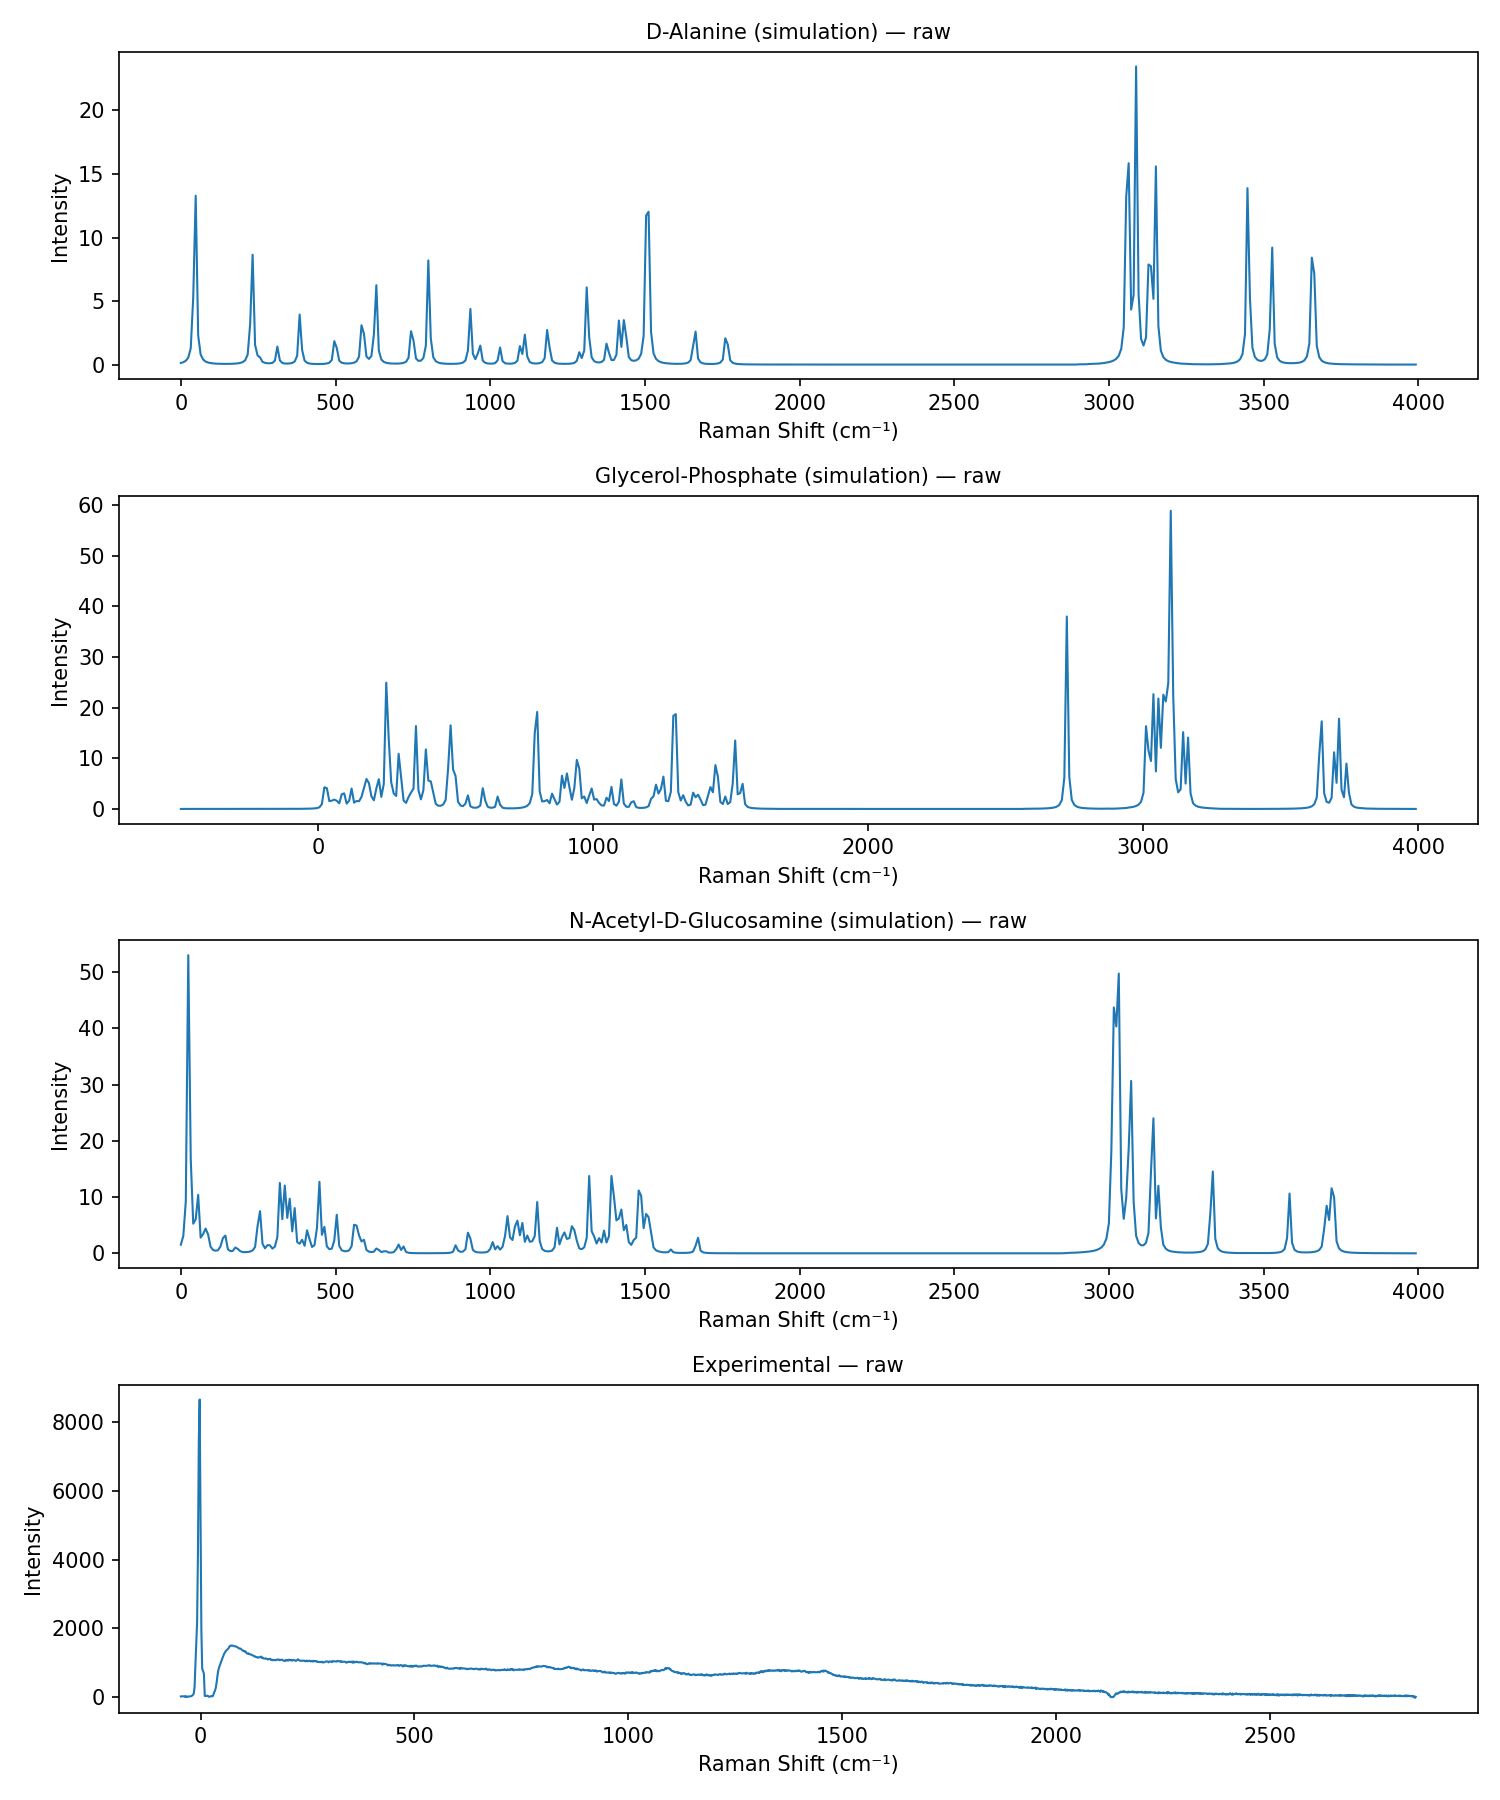


individual_components.png


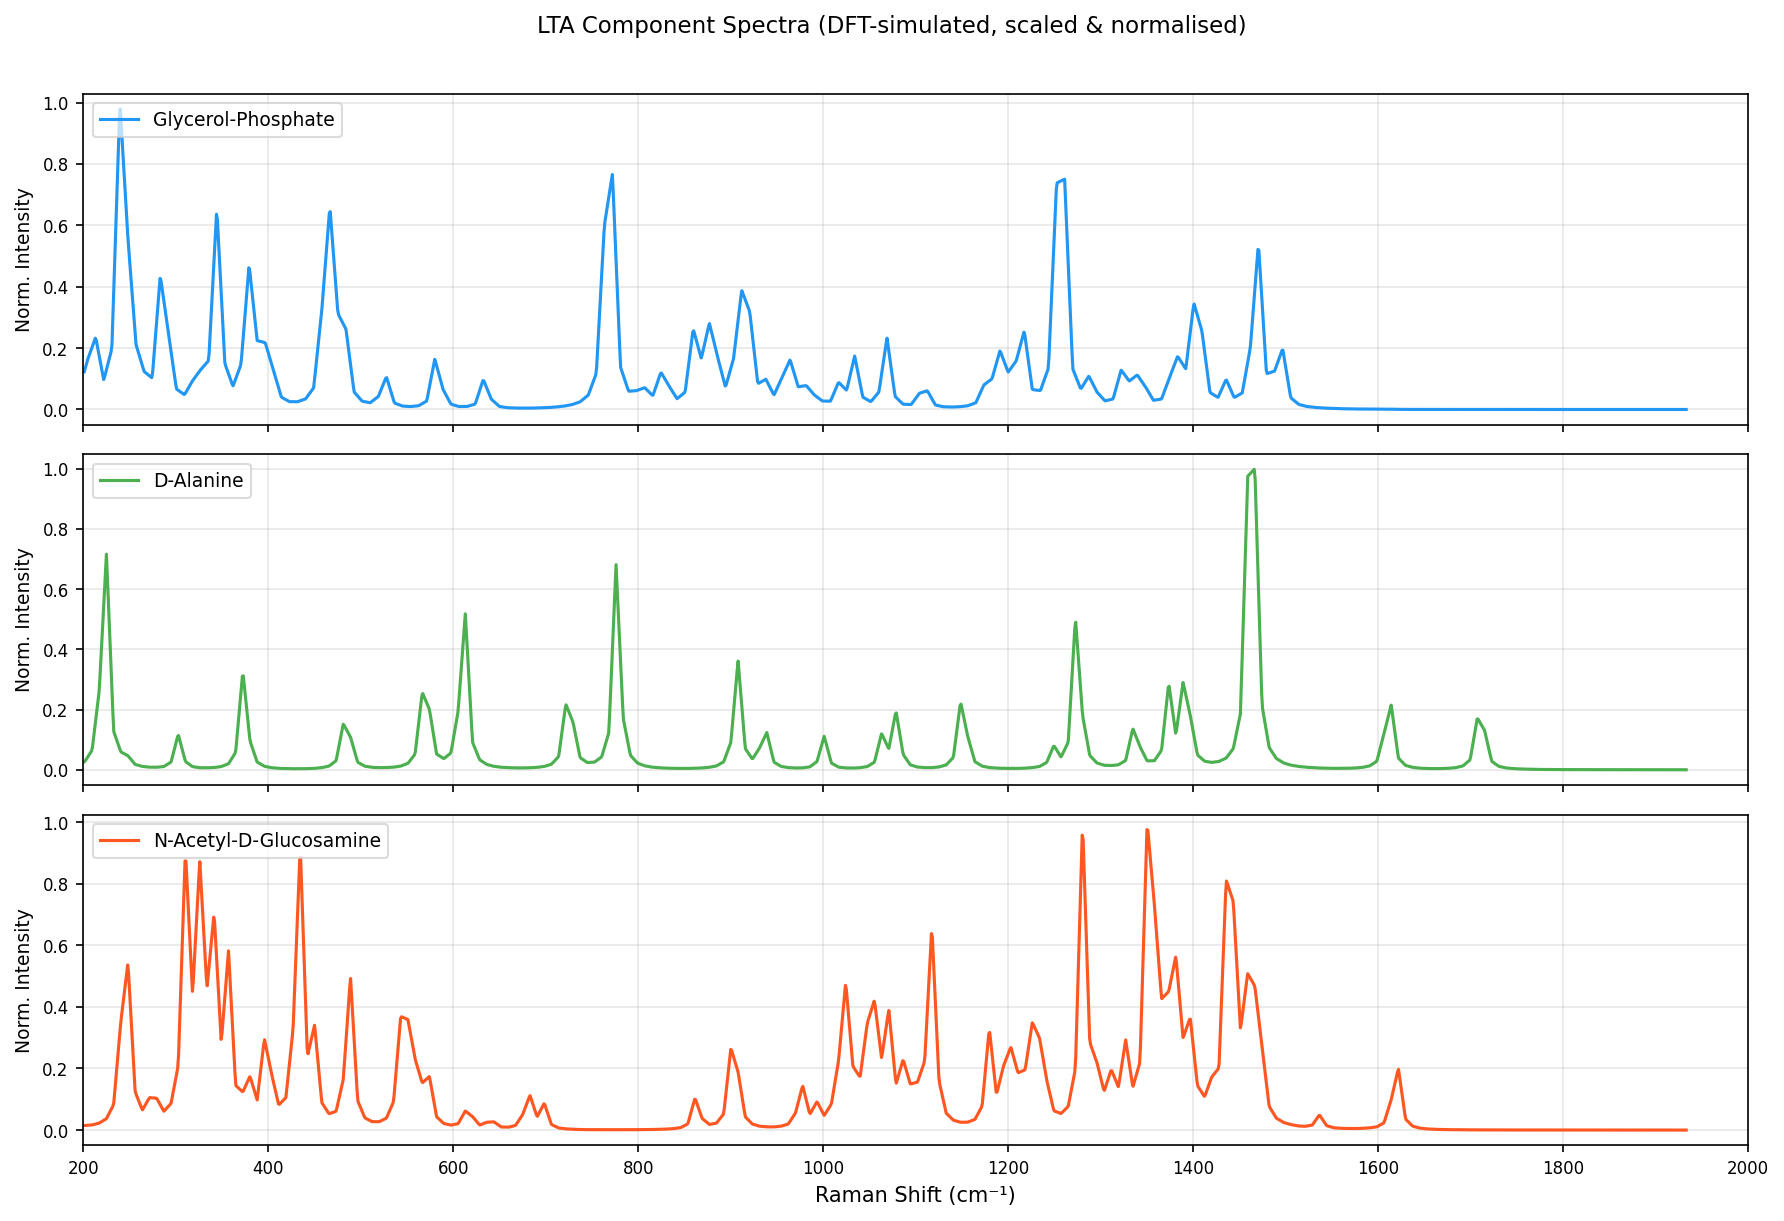


scaling_comparison.png


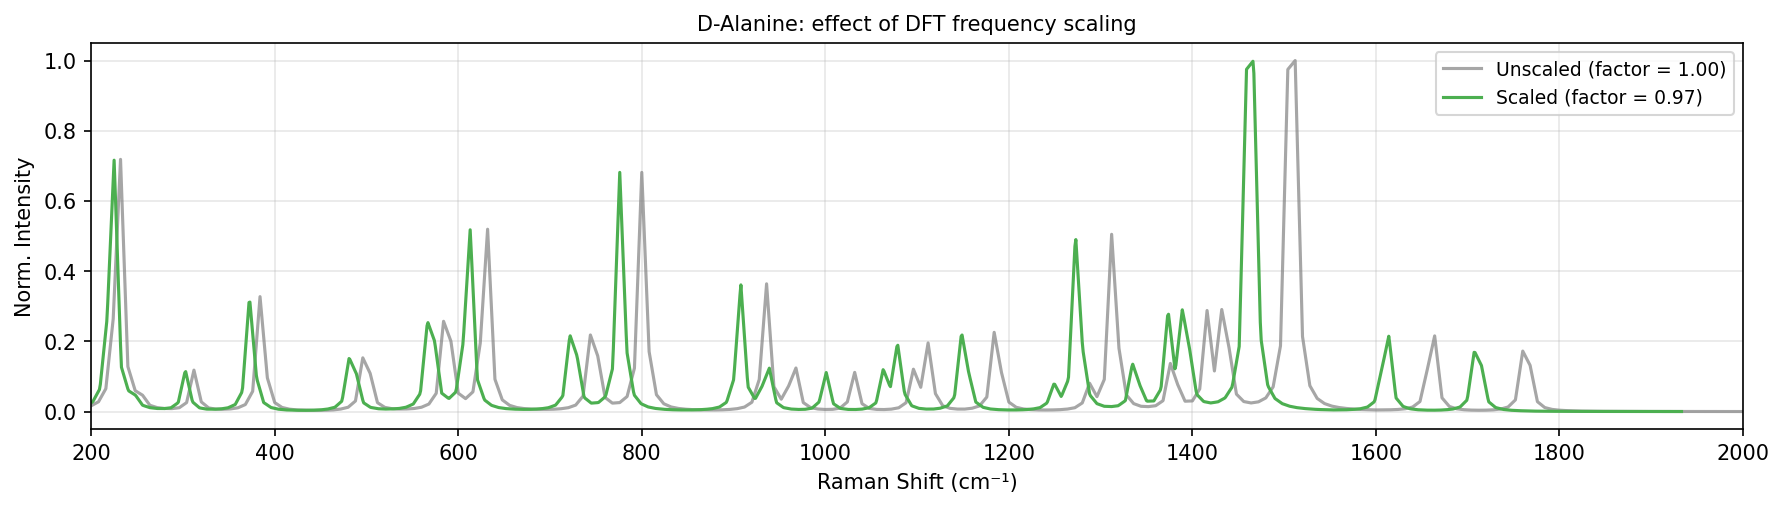


composite_models.png


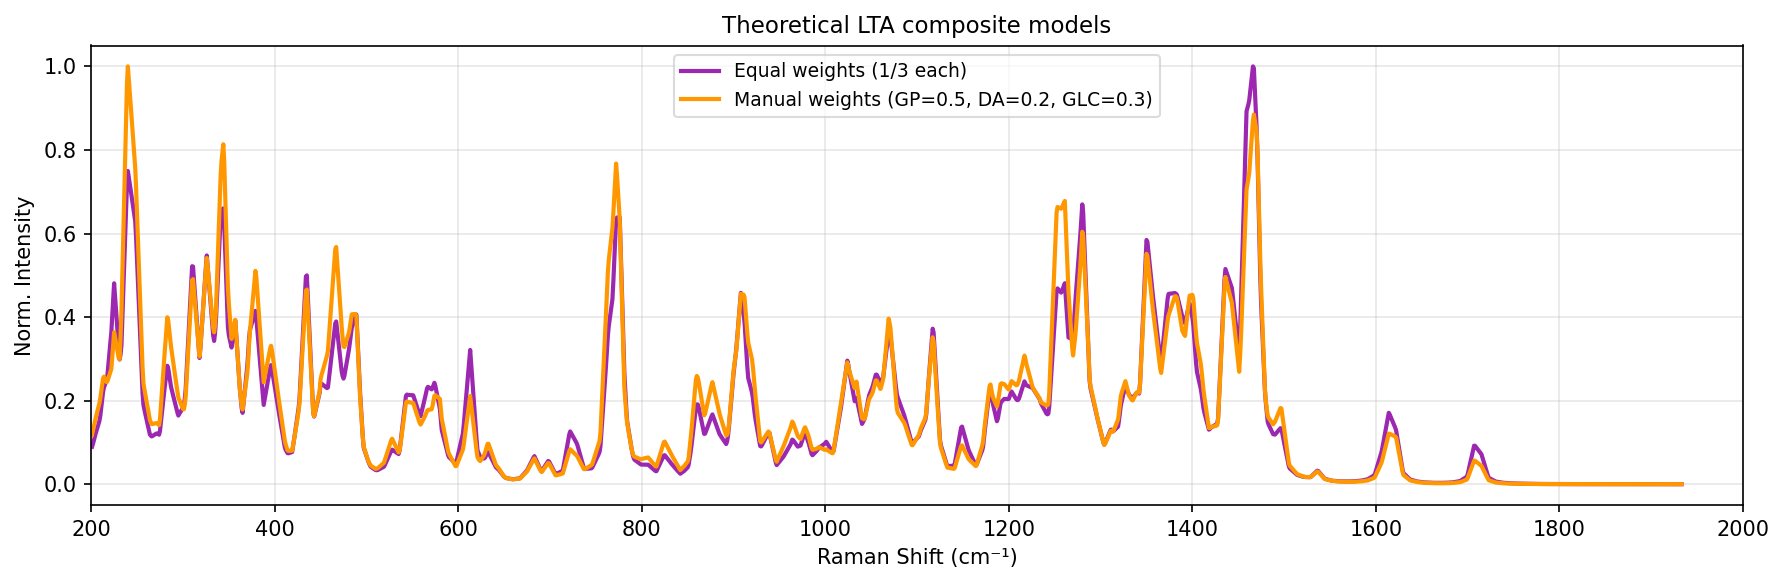


fit_and_residual.png


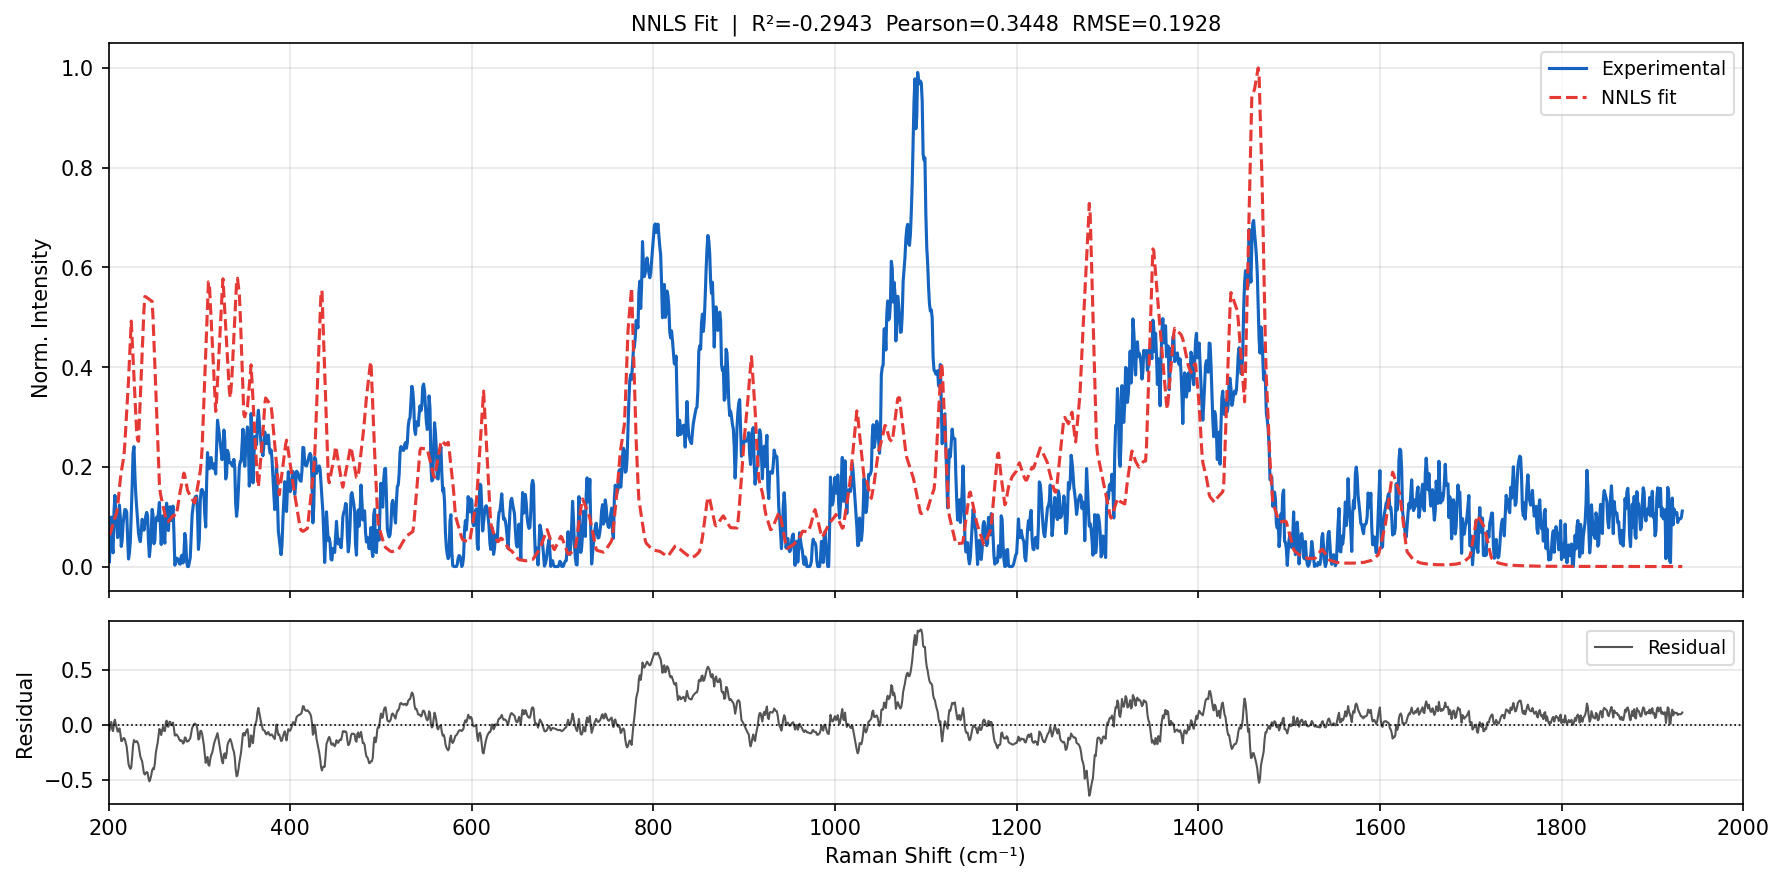


fitted_weights.png


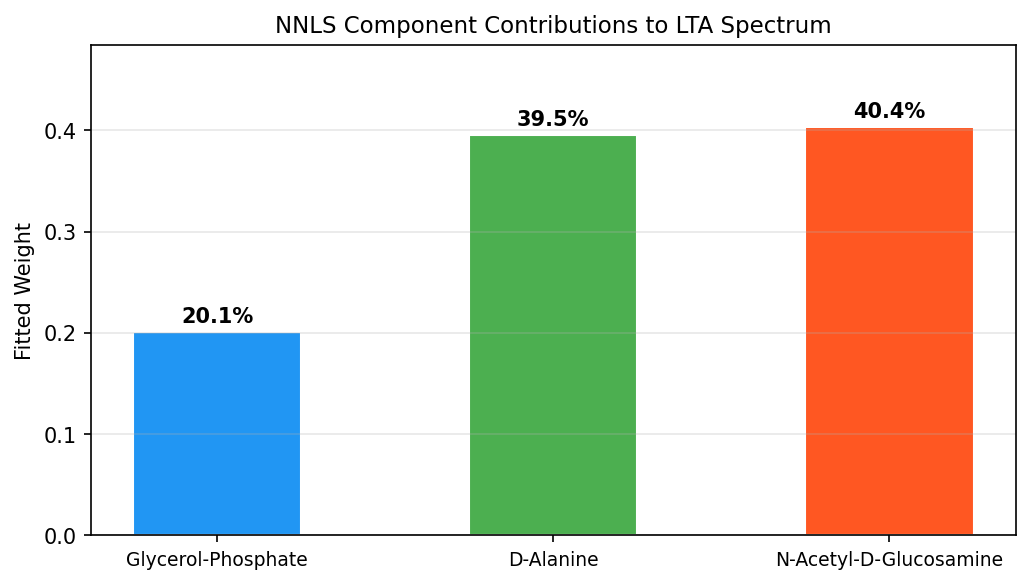


final_overlay.png


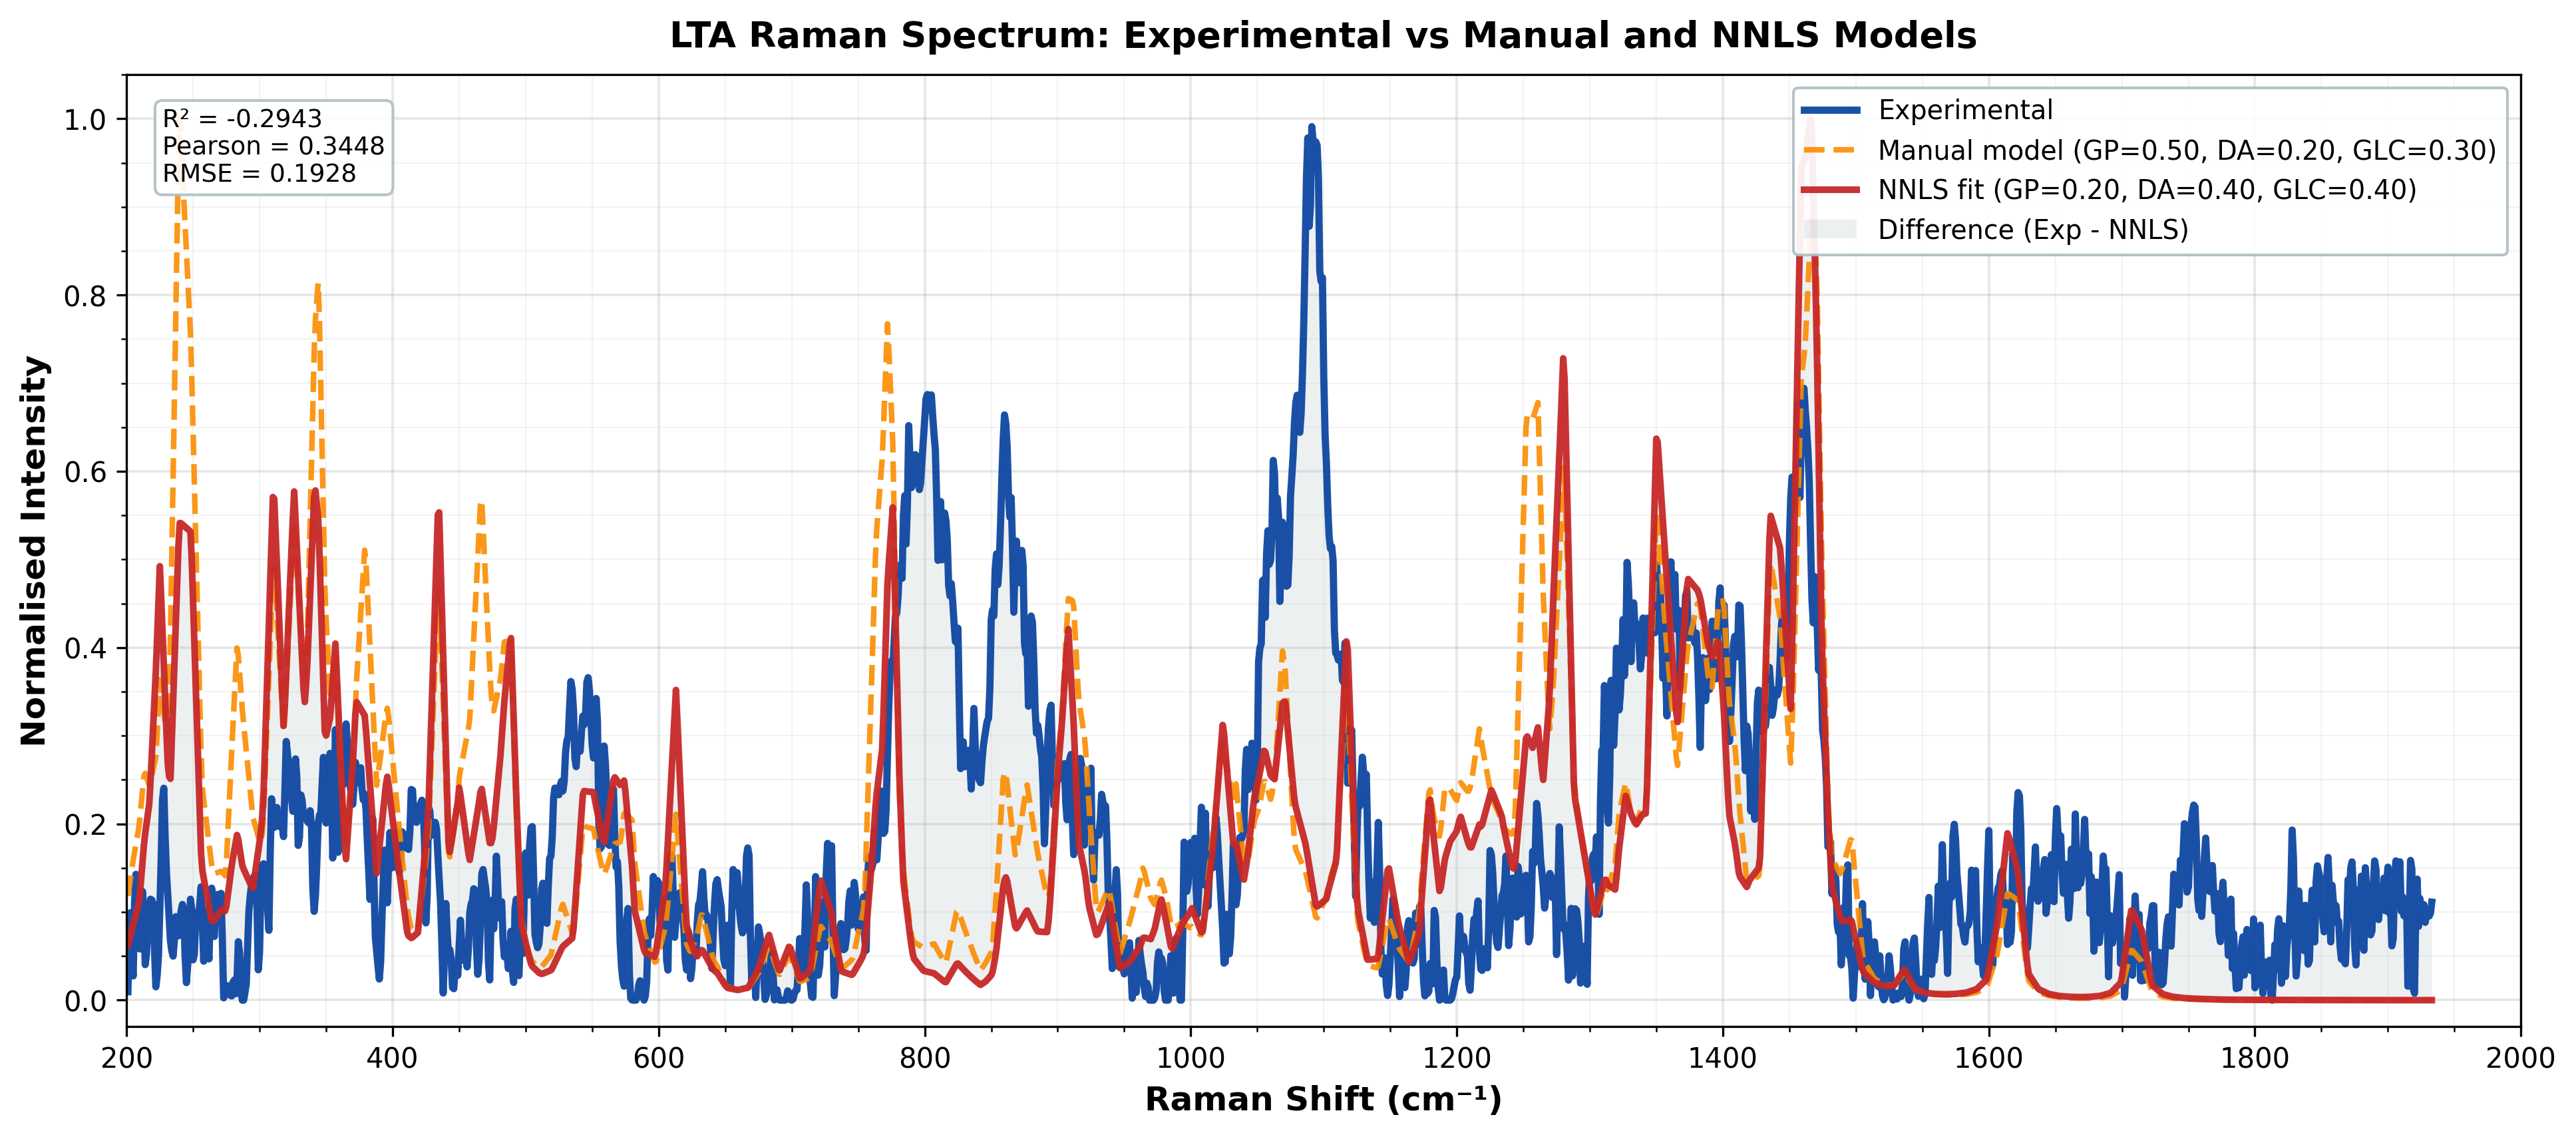


annotated_regions.png


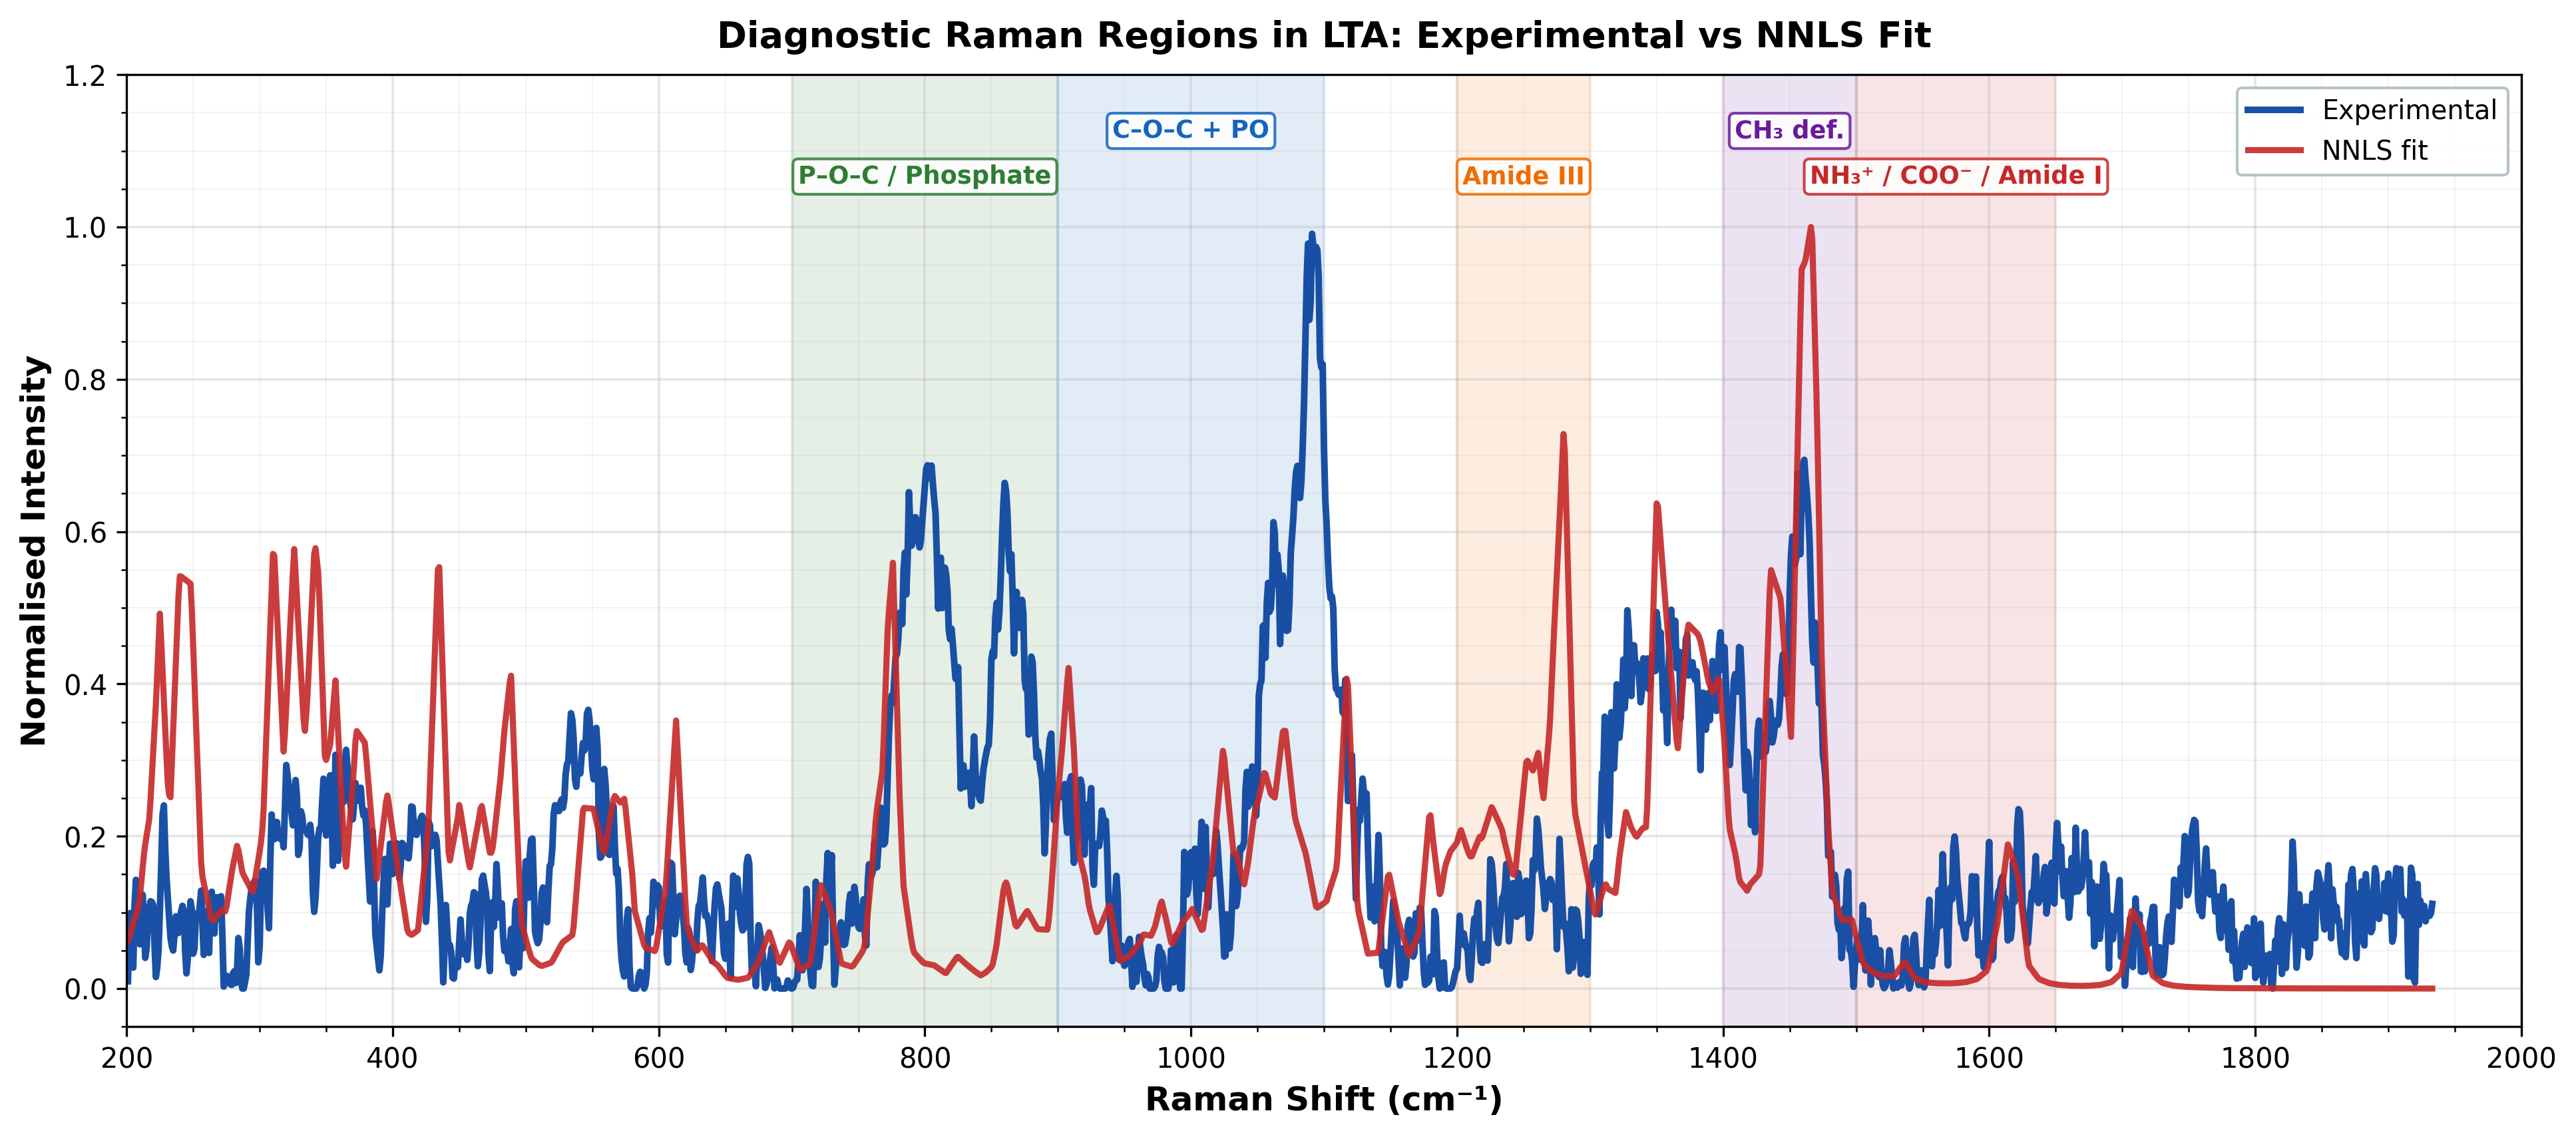


annotated_peaks_final.png


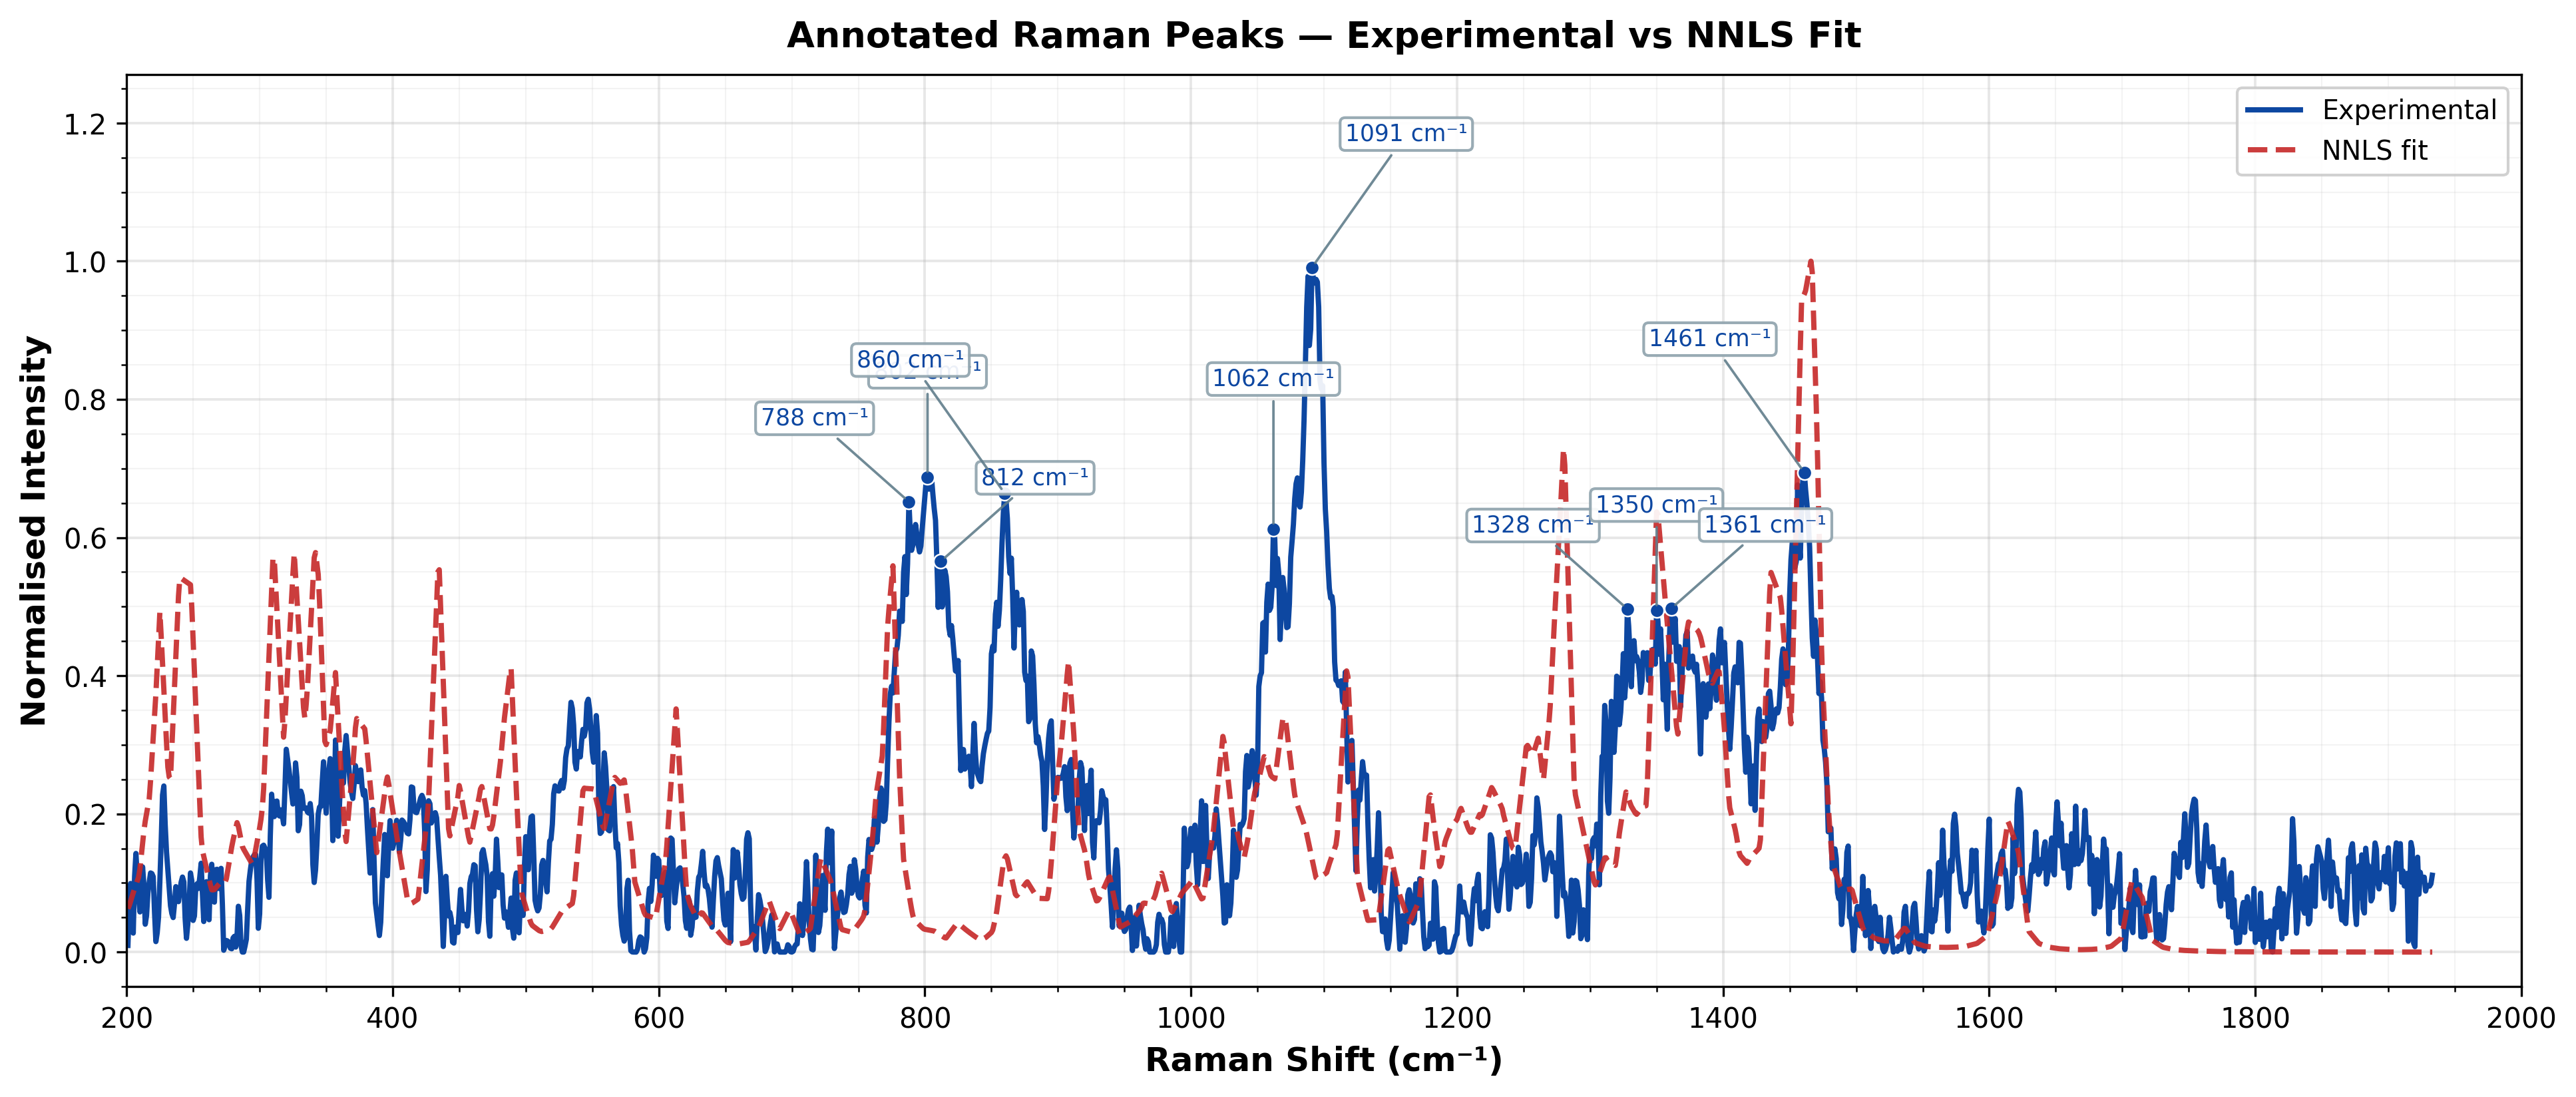

In [5]:
# CELL 32 — FINAL COMPLETION MESSAGE

from IPython.display import Image, display

output_files = [
    '00_raw_preview.png',
    'individual_components.png/svg/pdf',
    'scaling_comparison.png',
    'composite_models.csv',
    'composite_models.png/svg/pdf',
    'peaks_gp.csv',
    'peaks_da.csv',
    'peaks_glc.csv',
    'peaks_lta_manual.csv',
    'optimized_fit_spectrum.csv',
    'fit_metrics.csv',
    'fitted_weights.csv',
    'residual.csv',
    'fit_and_residual.png/svg/pdf',
    'fitted_weights.png',
    'final_overlay.png/svg/pdf',
    'annotated_regions.png/svg/pdf',
    'annotated_peaks_final.png',
    'final_summary_report.txt',
    'LTA_complete_results.xlsx',
]

print('=' * 55)
print('  Analysis completed successfully.')
print(f'  Outputs saved to: {output_dir}')
print('=' * 55)
print()
for f in output_files:
    print(f'  ✓  {f}')

# Also render key output images in this cell for quick review.
image_files = [
    '00_raw_preview.png',
    'individual_components.png',
    'scaling_comparison.png',
    'composite_models.png',
    'fit_and_residual.png',
    'fitted_weights.png',
    'final_overlay.png',
    'annotated_regions.png',
    'annotated_peaks_final.png',
]

print('\n' + '=' * 55)
print('  Preview Images')
print('=' * 55)
for img_name in image_files:
    img_path = os.path.join(output_dir, img_name)
    if os.path.exists(img_path):
        print(f'\n{img_name}')
        display(Image(filename=img_path))
    else:
        print(f'\n[missing] {img_name}')

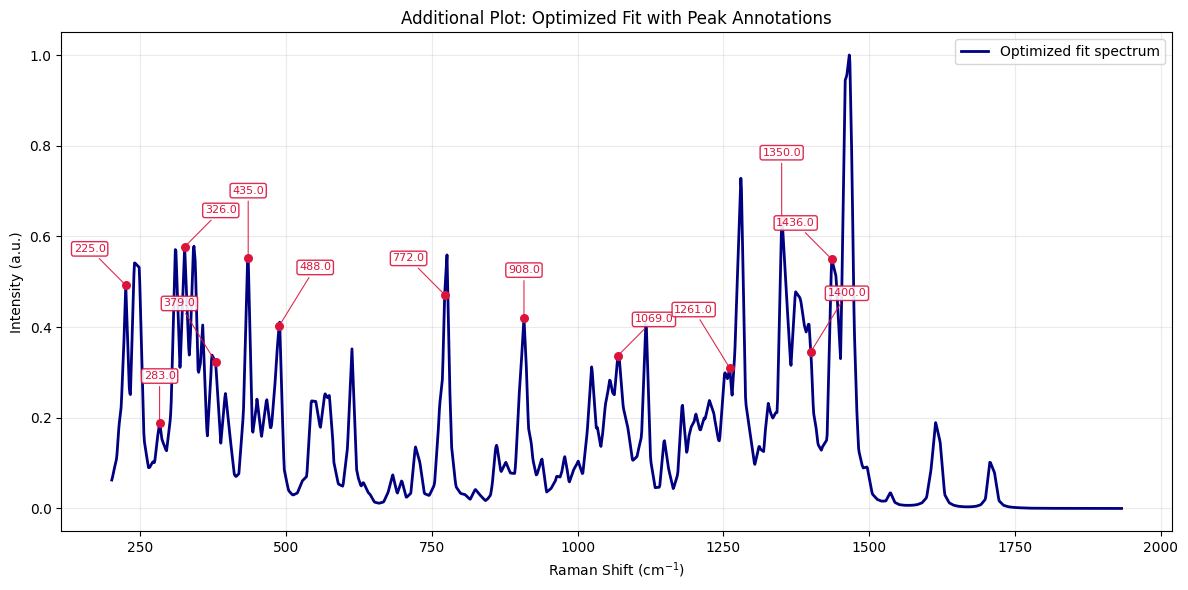

In [3]:
# NEW CELL — Additional graph with peak annotations
import os
import pandas as pd
import matplotlib.pyplot as plt

# Make this cell runnable independently if settings cells were not executed yet.
output_dir = globals().get('output_dir', os.path.join(os.getcwd(), 'results'))

fit_csv = os.path.join(output_dir, 'optimized_fit_spectrum.csv')
peaks_csv = os.path.join(output_dir, 'peaks_lta_manual.csv')

if not os.path.exists(peaks_csv):
    peaks_csv = os.path.join(output_dir, 'peaks_gp.csv')

if os.path.exists(fit_csv) and os.path.exists(peaks_csv):
    fit_df = pd.read_csv(fit_csv)
    peaks_df = pd.read_csv(peaks_csv)

    # Find x/y columns from the fit spectrum CSV
    x_candidates = ['wavenumber', 'raman_shift', 'x', 'Wavenumber', 'RamanShift']
    y_candidates = ['fitted', 'fit', 'intensity', 'y', 'Intensity', 'LTA_fit']
    xcol = next((c for c in x_candidates if c in fit_df.columns), fit_df.columns[0])
    ycol = next((c for c in y_candidates if c in fit_df.columns), fit_df.columns[1])

    # Find peak position column from peak CSV
    peak_x_candidates = ['center', 'position', 'peak_position', 'wavenumber', 'x', 'mu', 'RamanShift']
    peak_col = next((c for c in peak_x_candidates if c in peaks_df.columns), peaks_df.columns[0])

    x = fit_df[xcol].to_numpy()
    y = fit_df[ycol].to_numpy()

    plt.figure(figsize=(12, 6))
    plt.plot(x, y, color='navy', lw=2, label='Optimized fit spectrum')

    # Keep labels readable by only annotating peaks separated by a minimum x-distance.
    peak_values = sorted(peaks_df[peak_col].dropna().to_numpy())
    x_span = float(x.max() - x.min()) if len(x) > 1 else 1.0
    min_sep = max(12.0, 0.02 * x_span)
    filtered_peaks = []
    for px in peak_values:
        if not filtered_peaks or abs(px - filtered_peaks[-1]) >= min_sep:
            filtered_peaks.append(px)

    offset_templates = [(-26, 24), (0, 32), (26, 24), (-26, 40), (0, 46), (26, 40)]

    for i, px in enumerate(filtered_peaks):
        idx = (abs(x - px)).argmin()
        py = y[idx]
        plt.scatter(px, py, color='crimson', s=30, zorder=3)
        dx, dy = offset_templates[i % len(offset_templates)]
        plt.annotate(
            f'{px:.1f}',
            (px, py),
            textcoords='offset points',
            xytext=(dx, dy),
            ha='center',
            fontsize=8,
            color='crimson',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='crimson', alpha=0.9),
            arrowprops=dict(arrowstyle='-', color='crimson', lw=0.8, alpha=0.9, shrinkA=2, shrinkB=2),
            zorder=4,
        )

    plt.xlabel('Raman Shift (cm$^{-1}$)')
    plt.ylabel('Intensity (a.u.)')
    plt.title('Additional Plot: Optimized Fit with Peak Annotations')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Required files not found for annotated peak plot.')
    print(f'Missing fit file: {fit_csv} -> {os.path.exists(fit_csv)}')
    print(f'Missing peaks file: {peaks_csv} -> {os.path.exists(peaks_csv)}')